In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
os.makedirs('nilm_datasets', exist_ok=True)
print('Imports OK')

Imports OK


In [ ]:
ampd = pd.read_csv('Electricity_P.csv')

drop_cols = ['MHE', 'RSE', 'GRE', 'B1E', 'BME', 'EQE', 'OFE', 'UTE',
             'B2E', 'DNE', 'EBE', 'OUE', 'UNE', 'HTE', 'WOE','FRE']
ampd = ampd.drop(columns=[c for c in drop_cols if c in ampd.columns])

APPLIANCE_NAMES = {
    'CDE': 'Clothes Dryer',
    'CWE': 'Clothes Washer',
    'DWE': 'Dishwasher',
    'FGE': 'Kitchen Fridge',
    'HPE': 'Heat Pump',
    'TVE': 'TV',
    'WHE': 'Whole-House Meter',
}
ampd = ampd.rename(columns=APPLIANCE_NAMES)

MAINS_COL         = 'Whole-House Meter'
TARGET_APPLIANCES = [v for k, v in APPLIANCE_NAMES.items() if k != 'WHE']

#convert timestamp
ampd = ampd.rename(columns={ampd.columns[0]: 'time'})
ampd['time'] = pd.to_datetime(ampd['time'], unit='s', errors='coerce')
ampd = ampd.set_index('time').sort_index()

#clip negative values
for col in ampd.columns:
    ampd[col] = ampd[col].clip(lower=0)

print(f'Loaded: {len(ampd):,} rows')
print(f'Date range: {ampd.index[0].date()} to {ampd.index[-1].date()}')
print(f'Target appliances: {TARGET_APPLIANCES}')
ampd.head(3)

Loaded: 1,051,200 rows
Date range: 2012-04-01 to 2014-04-01
Target appliances: ['Clothes Dryer', 'Clothes Washer', 'Dishwasher', 'Kitchen Fridge', 'Heat Pump', 'TV']


,Whole-House Meter,Clothes Washer,Dishwasher,Heat Pump,Clothes Dryer,Kitchen Fridge,TV
time,,,,,,,
2012-04-01 07:00:00,918,0,0,36,0,0,37
2012-04-01 07:01:00,913,0,0,37,0,0,37
2012-04-01 07:02:00,872,0,0,38,0,0,37


In [32]:
"""
app = 'Wall oven'
arr = ampd[app].values
is_on = (arr > 0).astype(int)
diff = np.diff(is_on, prepend=0)
starts = np.where(diff == 1)[0]
ends = np.where(diff == -1)[0]
if len(starts) > len(ends):
    ends = np.append(ends, len(arr)-1)

durations = ends - starts
print(f"Median event duration : {np.median(durations):.0f} min")
print(f"Mean event duration   : {np.mean(durations):.0f} min")
print(f"% events under 5 min  : {(durations < 5).mean()*100:.1f}%")
print(f"% events under 15 min : {(durations < 15).mean()*100:.1f}%")
print(f"% events over 30 min  : {(durations > 30).mean()*100:.1f}%")
Median event duration : 1 min
Mean event duration   : 2 min
% events under 5 min  : 99.5%
% events under 15 min : 99.5%
% events over 30 min  : 0.5%


THIS WHY WE DROPPED WALL OVEN  99.5% of events are under 5 minutes, so the model cant learn meaningful ON/OFF patternS
"""


'\napp = \'Wall oven\'\narr = ampd[app].values\nis_on = (arr > 0).astype(int)\ndiff = np.diff(is_on, prepend=0)\nstarts = np.where(diff == 1)[0]\nends = np.where(diff == -1)[0]\nif len(starts) > len(ends):\n    ends = np.append(ends, len(arr)-1)\n\ndurations = ends - starts\nprint(f"Median event duration : {np.median(durations):.0f} min")\nprint(f"Mean event duration   : {np.mean(durations):.0f} min")\nprint(f"% events under 5 min  : {(durations < 5).mean()*100:.1f}%")\nprint(f"% events under 15 min : {(durations < 15).mean()*100:.1f}%")\nprint(f"% events over 30 min  : {(durations > 30).mean()*100:.1f}%")\nMedian event duration : 1 min\nMean event duration   : 2 min\n% events under 5 min  : 99.5%\n% events under 15 min : 99.5%\n% events over 30 min  : 0.5%\n\n\nTHIS WHY WE DROPPED WALL OVEN  99.5% of events are under 5 minutes, so the model cant learn meaningful ON/OFF patternS\n'

In [ ]:
WATTS_ON_THRESHOLD = 50.0


for app in TARGET_APPLIANCES:
    if app not in ampd.columns:
        continue
    thr = WATTS_ON_THRESHOLD
    before = ampd[app].mean()
    n_before = (ampd[app] > 0).sum()
    ampd[app] = ampd[app].where(ampd[app] >= thr, other=0.0)
    after = ampd[app].mean()
    n_after = (ampd[app] > 0).sum()
    pct_zeroed = (1 - n_after / max(n_before, 1)) * 100
    print(f'{app:<20} thr={thr:.0f}W  {before:>8.1f} → {after:>8.1f}  {pct_zeroed:>6.1f}% zeroed')

print(f'\nDone. Values below {WATTS_ON_THRESHOLD}W set to 0.')

Clothes Dryer        thr=50W      53.1 →     53.0    14.1% zeroed
Clothes Washer       thr=50W       4.4 →      4.2    28.2% zeroed
Dishwasher           thr=50W      14.9 →     14.8    44.6% zeroed
Kitchen Fridge       thr=50W      50.4 →     49.8    25.9% zeroed
Heat Pump            thr=50W     168.3 →    135.0    92.6% zeroed
TV                   thr=50W      41.0 →     19.2    90.8% zeroed

Done. Values below 50.0W set to 0.


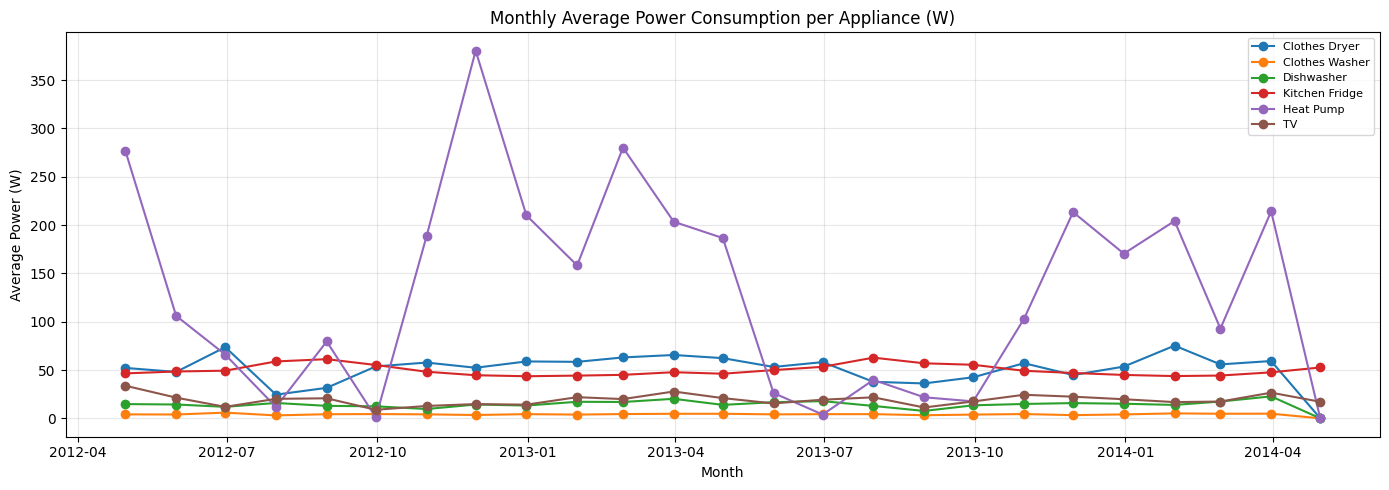

In [ ]:
monthly = ampd[TARGET_APPLIANCES].resample('ME').mean()
fig, ax = plt.subplots(figsize=(14, 5))
for col in monthly.columns:
    ax.plot(monthly.index, monthly[col], marker='o', label=col)
ax.set_title('Monthly Average Power Consumption per Appliance (W)')
ax.set_xlabel('Month')
ax.set_ylabel('Average Power (W)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

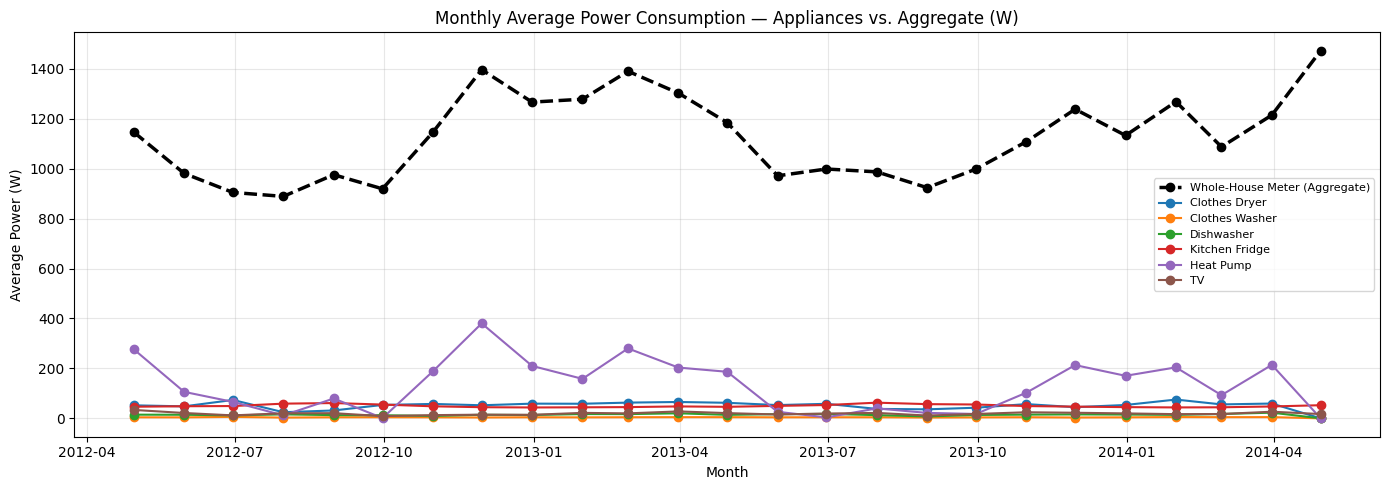

In [ ]:
monthly_apps = ampd[TARGET_APPLIANCES].resample('ME').mean()
monthly_agg  = ampd[MAINS_COL].resample('ME').mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_agg.index, monthly_agg.values,
        marker='o', linewidth=2.5, linestyle='--',
        color='black', label=f'{MAINS_COL} (Aggregate)')

for col in monthly_apps.columns:
    ax.plot(monthly_apps.index, monthly_apps[col], marker='o', label=col)

ax.set_title('Monthly Average Power Consumption — Appliances vs. Aggregate (W)')
ax.set_xlabel('Month')
ax.set_ylabel('Average Power (W)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

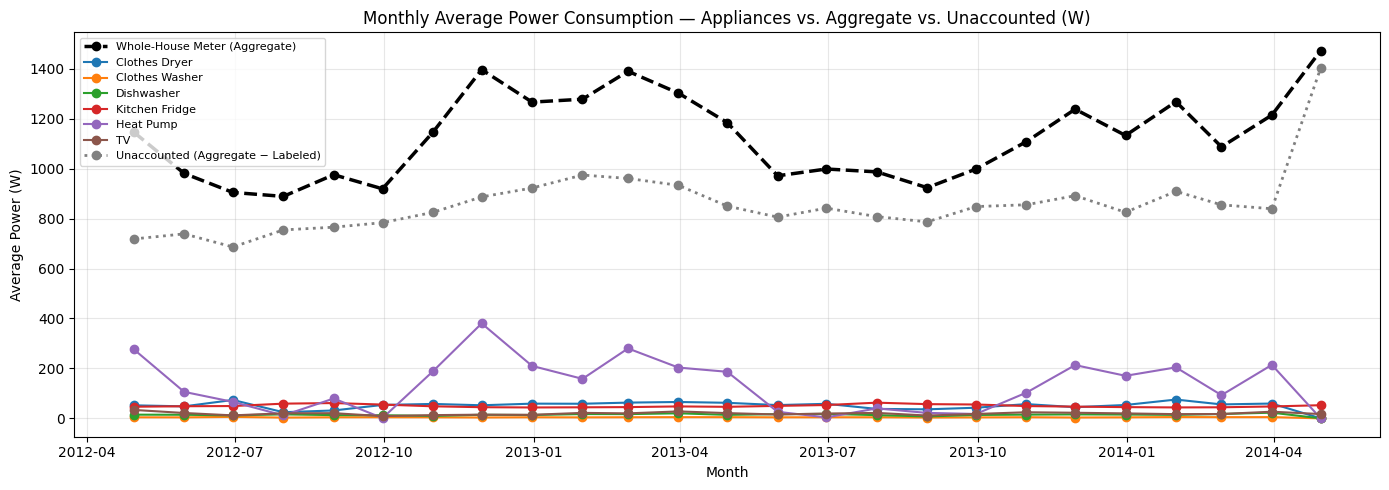

In [ ]:
monthly_apps = ampd[TARGET_APPLIANCES].resample('ME').mean()
monthly_agg  = ampd[MAINS_COL].resample('ME').mean()
monthly_bal  = (ampd[MAINS_COL] - ampd[TARGET_APPLIANCES].sum(axis=1)).clip(lower=0).resample('ME').mean()

fig, ax = plt.subplots(figsize=(14, 5))

#Aggregate
ax.plot(monthly_agg.index, monthly_agg.values,
        marker='o', linewidth=2.5, linestyle='--',
        color='black', label=f'{MAINS_COL} (Aggregate)')

#appliances
for col in monthly_apps.columns:
    ax.plot(monthly_apps.index, monthly_apps[col], marker='o', label=col)

#balance
ax.plot(monthly_bal.index, monthly_bal.values,
        marker='o', linewidth=2.0, linestyle=':',
        color='gray', label='Unaccounted (Aggregate − Labeled)')

ax.set_title('Monthly Average Power Consumption — Appliances vs. Aggregate vs. Unaccounted (W)')
ax.set_xlabel('Month')
ax.set_ylabel('Average Power (W)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(f'{"Appliance":<20} {"Mean W":>8} {"Max W":>8} {"ON%":>8} {"Events est.":>12}')
print('-' * 60)
for app in TARGET_APPLIANCES:
    if app not in ampd.columns:
        continue
    s = ampd[app]
    is_on = s > 0
    # Estimate events: count ON->OFF transitions
    n_events = int((is_on.astype(int).diff() == 1).sum())
    print(f'{app:<20} {s.mean():>8.1f} {s.max():>8.0f} '
          f'{is_on.mean()*100:>7.1f}% {n_events:>12,}')

Appliance              Mean W    Max W      ON%  Events est.
------------------------------------------------------------
Clothes Dryer            53.0     5614     1.8%          471
Clothes Washer            4.2     1151     2.1%        4,362
Dishwasher               14.8      848     2.2%        2,036
Kitchen Fridge           49.8     1497    36.8%       30,307
Heat Pump               135.0     3701     7.4%        2,242
TV                       19.2      454     9.1%        1,333


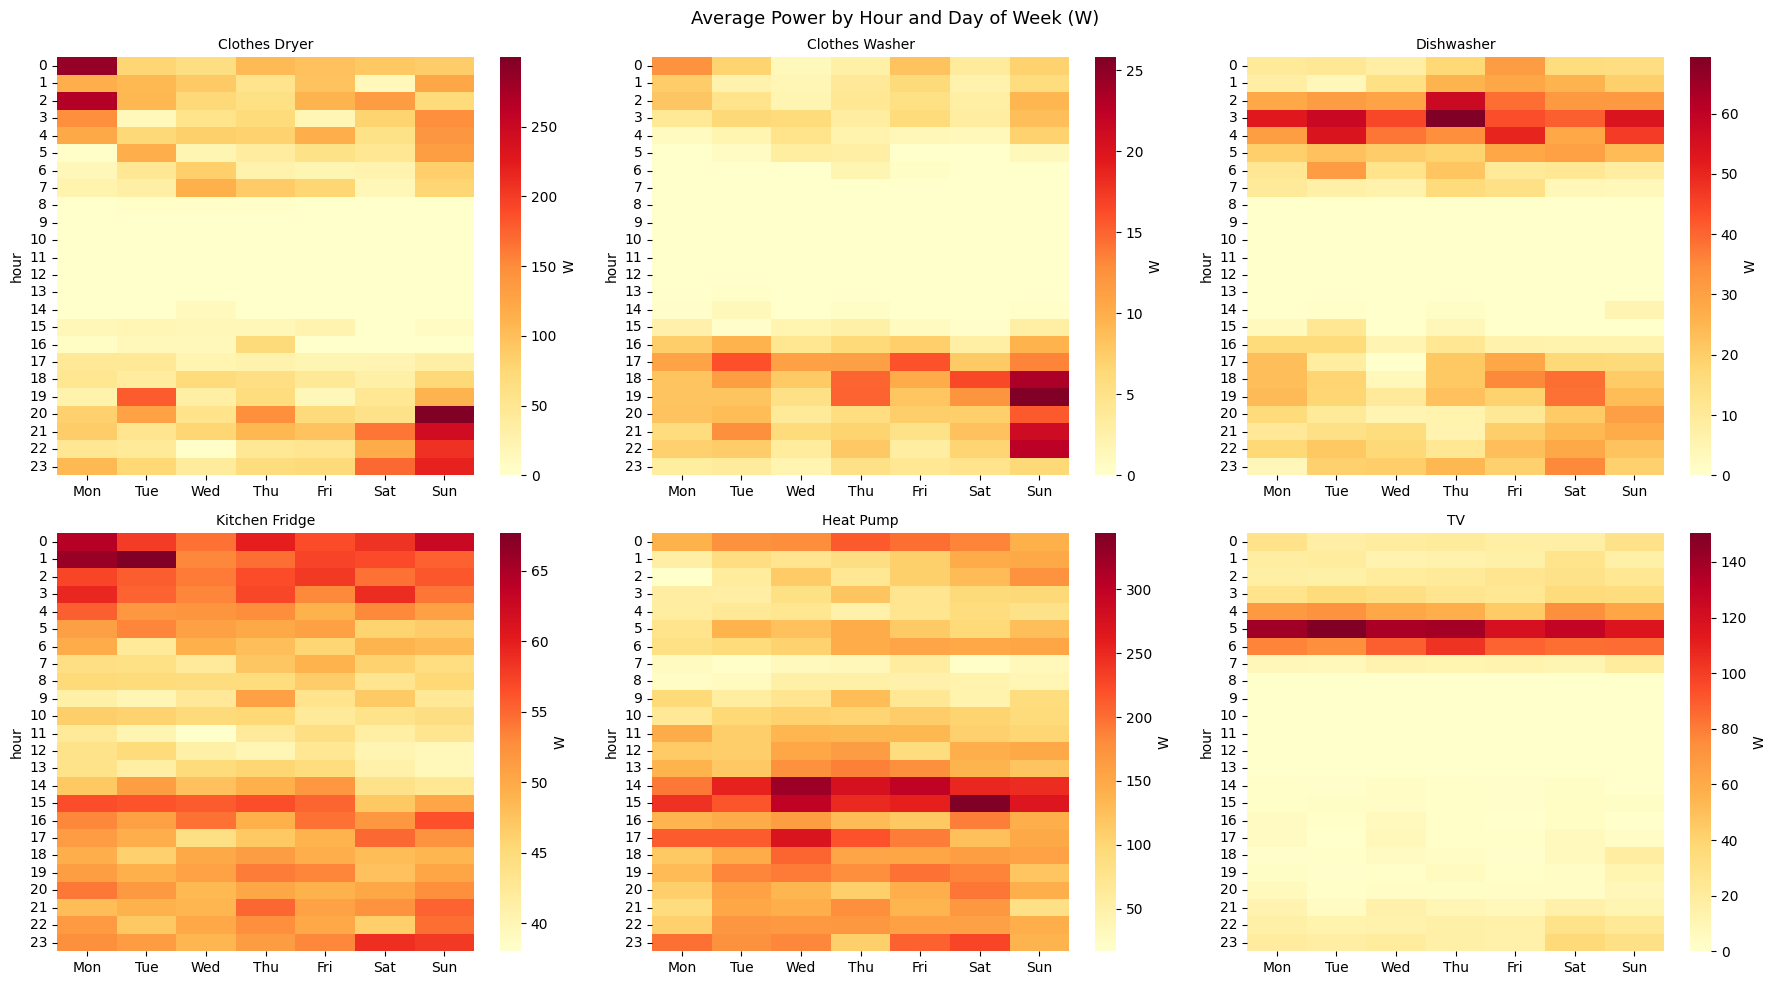

In [ ]:
#hour x day-of-week per appliance
df_eda = ampd.copy()
df_eda['hour']      = df_eda.index.hour
df_eda['dayofweek'] = df_eda.index.dayofweek
day_labels          = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

n_apps = len(TARGET_APPLIANCES)
ncols  = 3
nrows  = (n_apps + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, TARGET_APPLIANCES):
    pivot = df_eda.pivot_table(values=col, index='hour',
                                columns='dayofweek', aggfunc='mean')
    pivot.columns = day_labels
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'W'})
    ax.set_title(col, fontsize=10)

for ax in axes[n_apps:]:
    ax.set_visible(False)

plt.suptitle('Average Power by Hour and Day of Week (W)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
rows = []
for app in TARGET_APPLIANCES:
    if app not in ampd.columns:
        continue
    
    signal   = ampd[app]
    is_on    = (signal > 0).astype(int)
    diff     = np.diff(is_on.values, prepend=0)
    n_events = int((diff == 1).sum())
    
    rows.append({
        'Appliance'       : app,
        'Mean Power (W)'  : round(signal[signal > 0].mean(), 1),  # mean when ON
        'Max Power (W)'   : round(signal.max(), 1),
        'ON Time (%)'     : round(is_on.mean() * 100, 2),
        'ON Events (#)'   : n_events,
    })

summary = pd.DataFrame(rows).set_index('Appliance')
print(summary.to_string())

                Mean Power (W)  Max Power (W)  ON Time (%)  ON Events (#)
Appliance                                                                
Clothes Dryer           3006.0           5614         1.76            471
Clothes Washer           205.7           1151         2.06           4362
Dishwasher               658.0            848         2.25           2036
Kitchen Fridge           135.4           1497        36.77          30307
Heat Pump               1833.9           3701         7.36           2242
TV                       211.9            454         9.08           1333


In [10]:
n         = len(ampd)
val_start = int(n * 0.80)
val_end   = int(n * 0.85)

df_train = ampd.iloc[:val_start].copy()
df_val   = ampd.iloc[val_start:val_end].copy()
df_test  = ampd.iloc[val_end:].copy()

print(f'Total : {n:,} rows')
print(f'Train : {len(df_train):,}  '
      f'{df_train.index[0].date()} to {df_train.index[-1].date()}')
print(f'Val   : {len(df_val):,}  '
      f'{df_val.index[0].date()} to {df_val.index[-1].date()}')
print(f'Test  : {len(df_test):,}  '
      f'{df_test.index[0].date()} to {df_test.index[-1].date()}')

Total : 1,051,200 rows
Train : 840,960  2012-04-01 to 2013-11-06
Val   : 52,560  2013-11-06 to 2013-12-12
Test  : 157,680  2013-12-12 to 2014-04-01


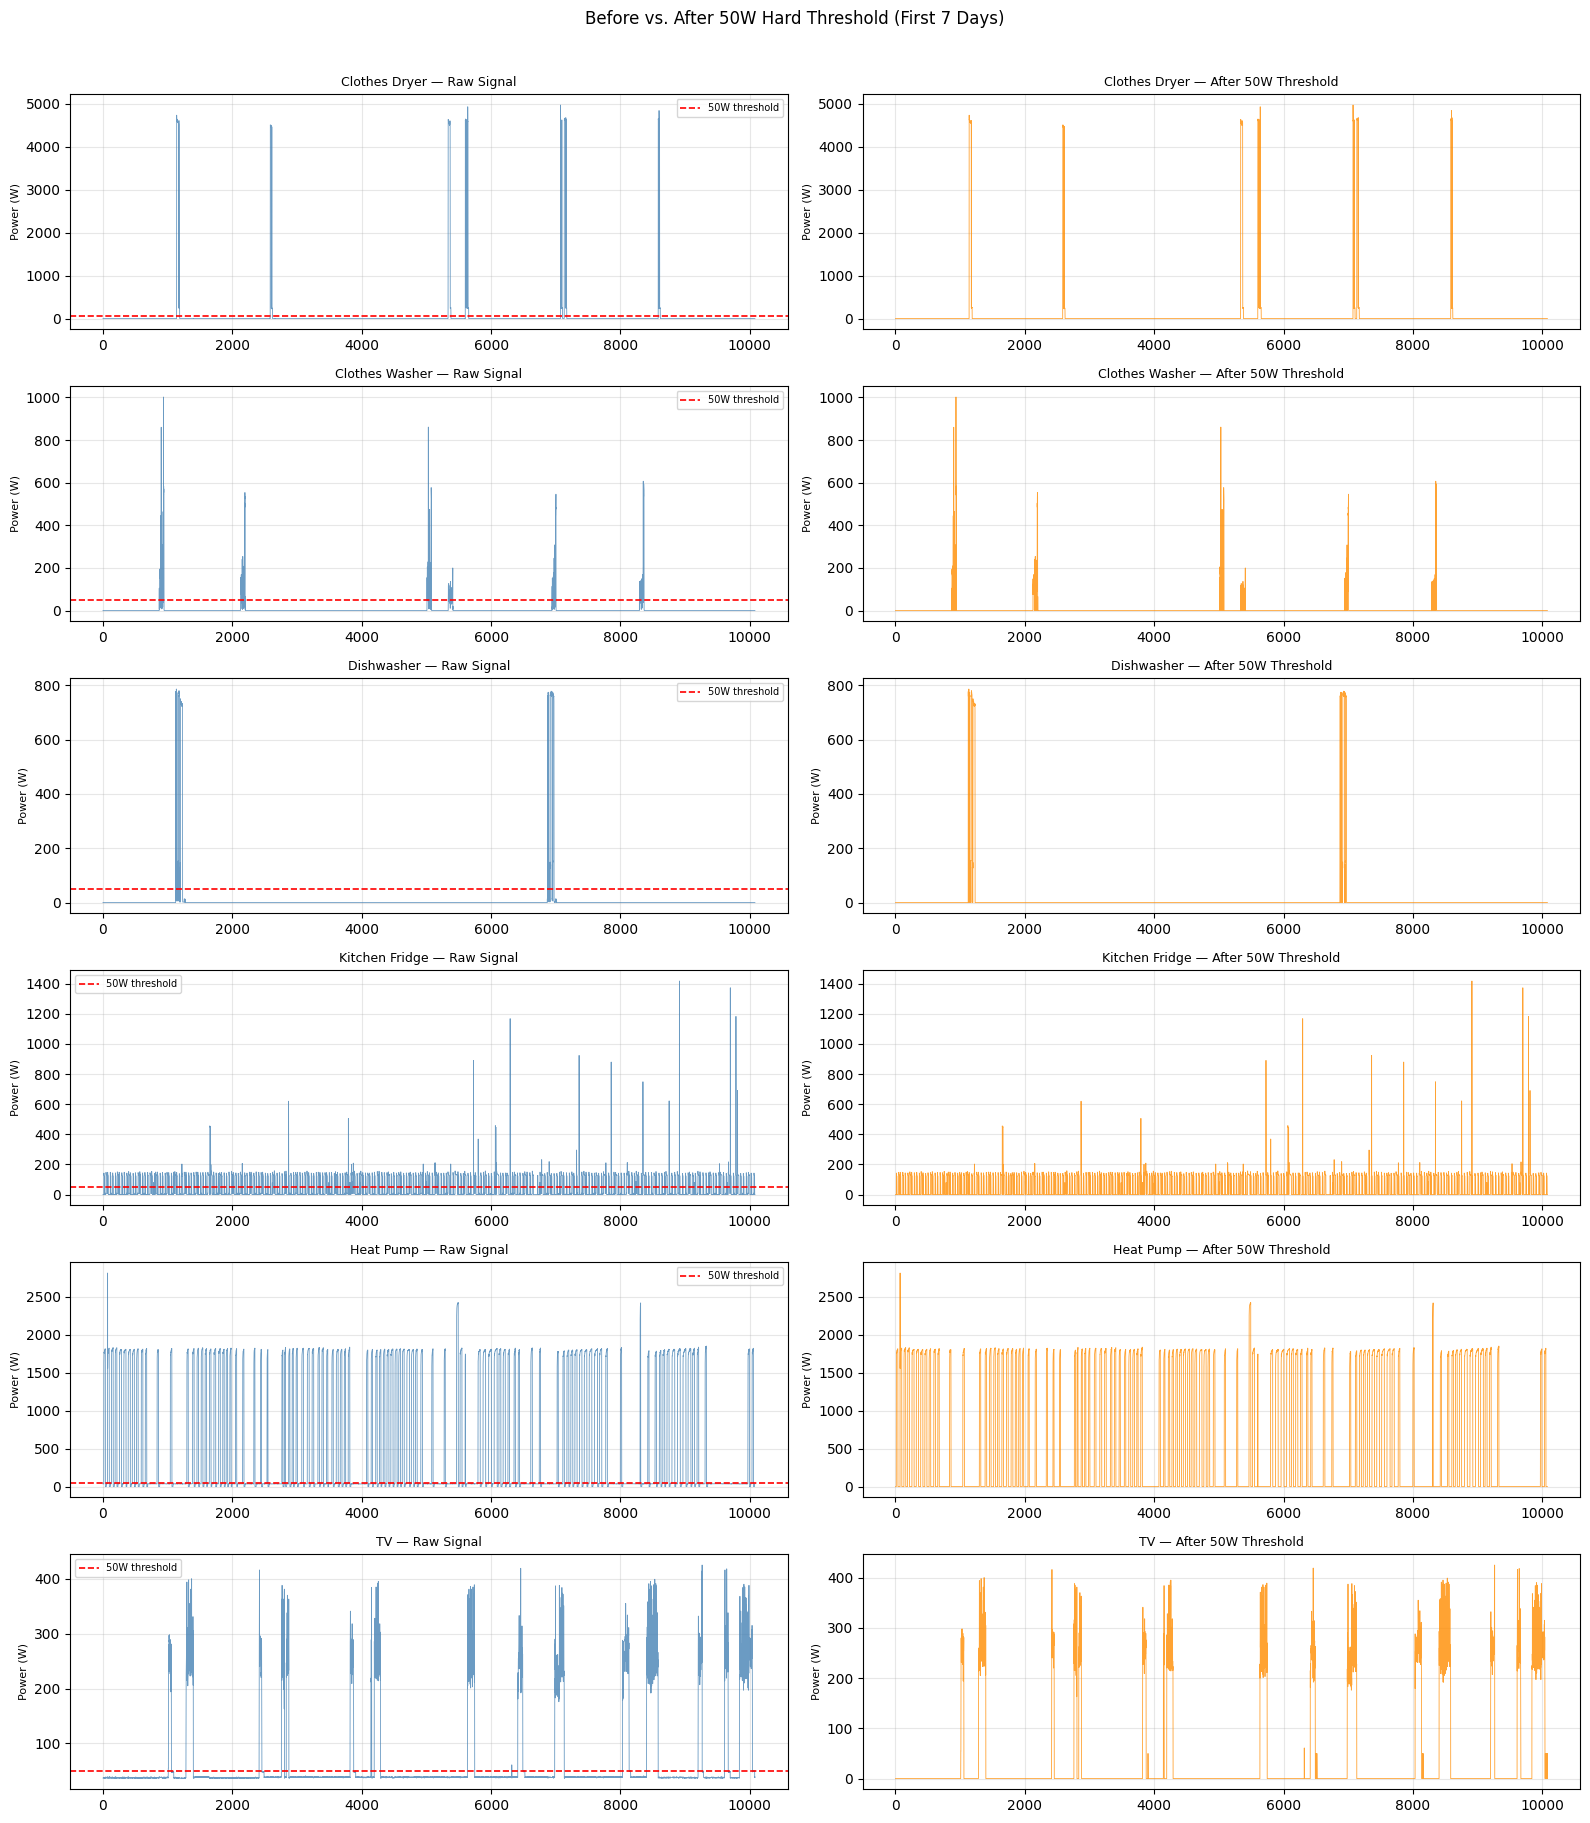

In [ ]:
fig, axes = plt.subplots(len(TARGET_APPLIANCES), 2, figsize=(16, 3 * len(TARGET_APPLIANCES)))

for i, app in enumerate(TARGET_APPLIANCES):
    if app not in ampd.columns:
        continue

    # Re-load raw signal for comparison (before threshold)
    raw = pd.read_csv('Electricity_P.csv')
    raw = raw.rename(columns={raw.columns[0]: 'time'})
    raw['time'] = pd.to_datetime(raw['time'], unit='s', errors='coerce')
    raw = raw.set_index('time').sort_index()
    raw_col = {v: k for k, v in APPLIANCE_NAMES.items()}.get(app)
    if raw_col not in raw.columns:
        continue

    raw_signal = raw[raw_col].clip(lower=0)
    clean_signal = ampd[app]

    # Sample one week for readability
    sample = raw_signal.iloc[:60*24*7]
    sample_clean = clean_signal.iloc[:60*24*7]

    axes[i, 0].plot(sample.values, color='steelblue', linewidth=0.6, alpha=0.8)
    axes[i, 0].axhline(50, color='red', linestyle='--', linewidth=1.2, label='50W threshold')
    axes[i, 0].set_title(f'{app} — Raw Signal', fontsize=9)
    axes[i, 0].set_ylabel('Power (W)', fontsize=8)
    axes[i, 0].legend(fontsize=7)
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(sample_clean.values, color='darkorange', linewidth=0.6, alpha=0.8)
    axes[i, 1].set_title(f'{app} — After 50W Threshold', fontsize=9)
    axes[i, 1].set_ylabel('Power (W)', fontsize=8)
    axes[i, 1].grid(True, alpha=0.3)

plt.suptitle('Before vs. After 50W Hard Threshold (First 7 Days)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

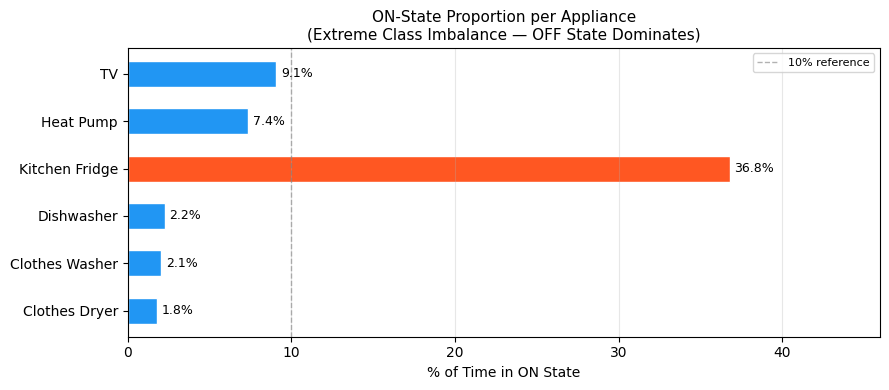

In [ ]:
on_pct = {}
for app in TARGET_APPLIANCES:
    if app in ampd.columns:
        on_pct[app] = (ampd[app] > 0).mean() * 100

apps   = list(on_pct.keys())
values = list(on_pct.values())
colors = ['#2196F3' if v < 10 else '#FF5722' for v in values]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(apps, values, color=colors, edgecolor='white', height=0.55)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('% of Time in ON State', fontsize=10)
ax.set_title('ON-State Proportion per Appliance\n(Extreme Class Imbalance — OFF State Dominates)',
             fontsize=11)
ax.axvline(10, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='10% reference')
ax.set_xlim(0, max(values) * 1.25)
ax.legend(fontsize=8)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def compute_norm_cap(series):
    """P99 cap computed from non-zero values."""
    arr     = series.clip(lower=0).values
    nonzero = arr[arr > 0]
    if len(nonzero) == 0:
        return 1.0
    return float(np.percentile(nonzero, 99))


def normalize_with_cap(arr, cap):
    """Normalise numpy array using precomputed cap. Clips to [0, 1]."""
    arr = np.clip(arr, 0, None).astype(np.float32)
    if cap <= 0:
        return arr
    return np.clip(arr / cap, 0.0, 1.0).astype(np.float32)


#norm caps from training data only
norm_caps = {}
norm_caps[MAINS_COL] = compute_norm_cap(df_train[MAINS_COL])
for app in TARGET_APPLIANCES:
    if app in df_train.columns:
        norm_caps[app] = compute_norm_cap(df_train[app])

print(f'{"Column":<25} {"Cap (W)":>10}')
print('-' * 37)
for k, v in norm_caps.items():
    print(f'{k:<25} {v:>10.1f}')

# Save caps for use in pipeline notebook
pd.DataFrame([norm_caps]).to_csv('nilm_datasets/norm_caps.csv', index=False)
print('\nSaved: nilm_datasets/norm_caps.csv')

Column                       Cap (W)
-------------------------------------
Whole-House Meter             5369.0
Clothes Dryer                 5005.6
Clothes Washer                 907.0
Dishwasher                     823.0
Kitchen Fridge                 445.0
Heat Pump                     2484.0
TV                             360.0

Saved: nilm_datasets/norm_caps.csv


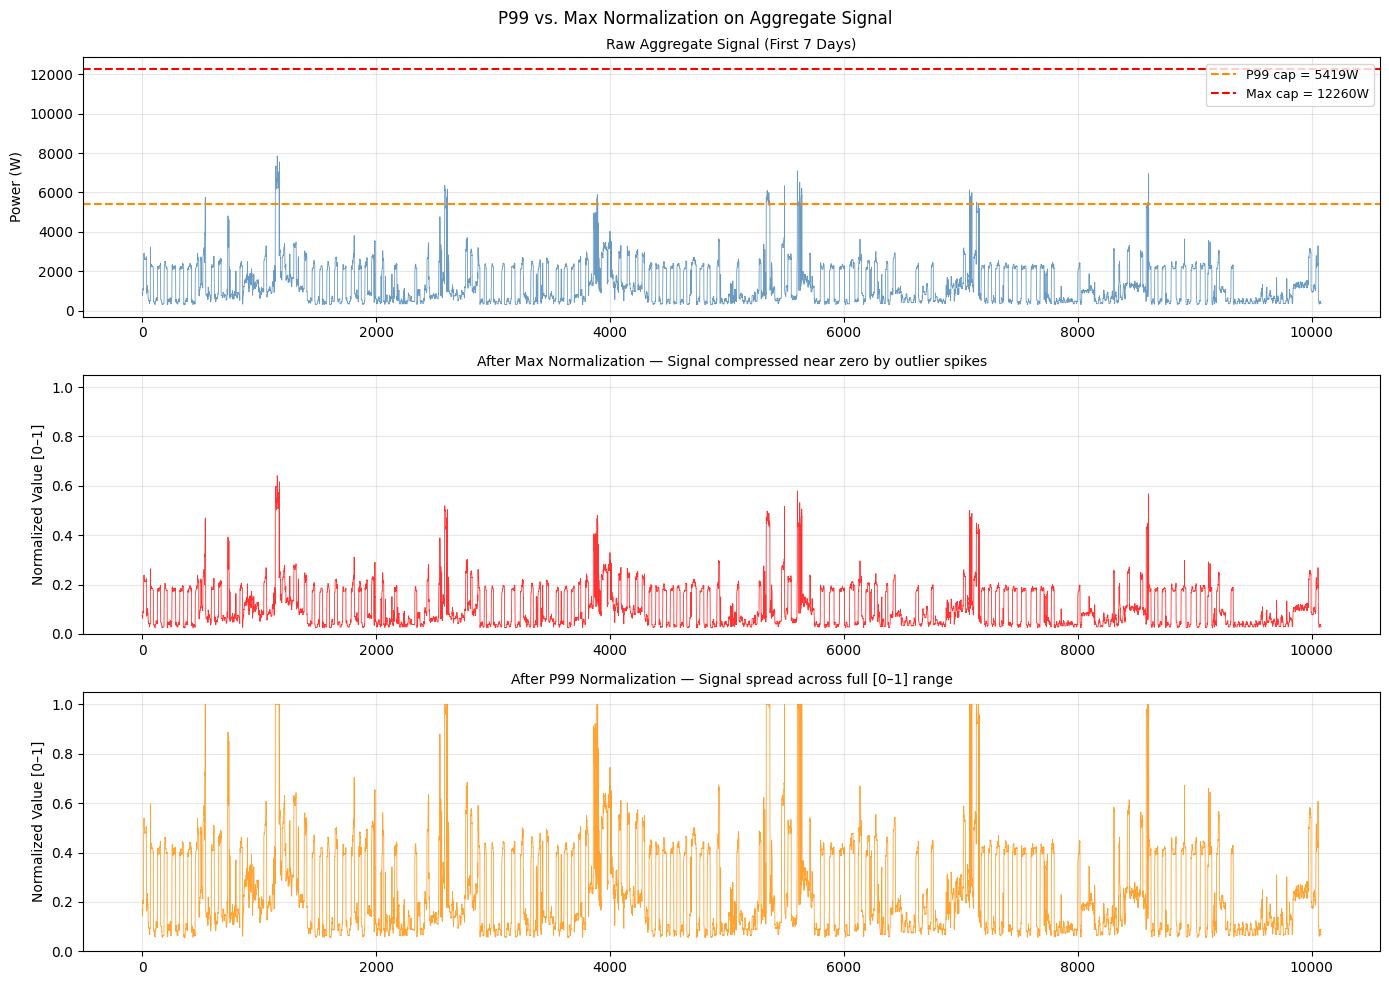

P99 cap : 5419.0 W
Max cap : 12260.0 W
Max norm — mean value : 0.0907  (how compressed the signal is)
P99 norm — mean value : 0.2038  (how spread the signal is)


In [ ]:
agg = ampd[MAINS_COL].values

p99 = np.percentile(agg[agg > 0], 99)
agg_max = agg.max()

norm_p99 = np.clip(agg / p99, 0, 1)
norm_max = np.clip(agg / agg_max, 0, 1)

sample = slice(0, 60 * 24 * 7)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(agg[sample], color='steelblue', linewidth=0.6, alpha=0.8)
axes[0].axhline(p99,     color='darkorange', linestyle='--', linewidth=1.5,
                label=f'P99 cap = {p99:.0f}W')
axes[0].axhline(agg_max, color='red',        linestyle='--', linewidth=1.5,
                label=f'Max cap = {agg_max:.0f}W')
axes[0].set_title('Raw Aggregate Signal (First 7 Days)', fontsize=10)
axes[0].set_ylabel('Power (W)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(norm_max[sample], color='red', linewidth=0.6, alpha=0.8)
axes[1].set_title('After Max Normalization — Signal compressed near zero by outlier spikes',
                  fontsize=10)
axes[1].set_ylabel('Normalized Value [0–1]')
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

axes[2].plot(norm_p99[sample], color='darkorange', linewidth=0.6, alpha=0.8)
axes[2].set_title('After P99 Normalization — Signal spread across full [0–1] range',
                  fontsize=10)
axes[2].set_ylabel('Normalized Value [0–1]')
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3)

plt.suptitle('P99 vs. Max Normalization on Aggregate Signal', fontsize=12)
plt.tight_layout()
plt.show()

print(f'P99 cap : {p99:.1f} W')
print(f'Max cap : {agg_max:.1f} W')
print(f'Max norm — mean value : {norm_max.mean():.4f}  (how compressed the signal is)')
print(f'P99 norm — mean value : {norm_p99.mean():.4f}  (how spread the signal is)')

In [ ]:
#minutes of zero context before and after each ON event
CONTEXT_CONFIG = {
    'Clothes Dryer' : {'lead': 30, 'trail': 30},
    'Clothes Washer': {'lead': 5,  'trail': 15},
    'Dishwasher'    : {'lead': 30, 'trail': 30},
    'Heat Pump'     : {'lead': 60, 'trail': 60},
    'Kitchen Fridge': {'lead': 10, 'trail': 10},
    'TV'            : {'lead': 2,  'trail': 2},   
}
#shorter events than this are considered noise
MIN_EVENT_DURATION = {
    'Clothes Dryer' : 10,
    'Clothes Washer': 10,
    'Dishwasher'    : 10,
    'Heat Pump'     : 5,
    'Kitchen Fridge': 2,
    'TV'            : 1,   
}
TARGET_APPLIANCES = [
    'Clothes Washer', 'Dishwasher', 'Clothes Dryer',
    'Heat Pump',
    'TV', 'Kitchen Fridge', 'Hot Water'
]

print(f'{"Appliance":<20} {"Lead (min)":>11} {"Trail (min)":>12} {"Min event (min)":>16}')
print('-' * 62)
for app in TARGET_APPLIANCES:
    if app not in CONTEXT_CONFIG:
        continue
    c = CONTEXT_CONFIG[app]
    m = MIN_EVENT_DURATION[app]
    print(f'{app:<20} {c["lead"]:>11} {c["trail"]:>12} {m:>16}')

Appliance             Lead (min)  Trail (min)  Min event (min)
--------------------------------------------------------------
Clothes Washer                 5           15               10
Dishwasher                    30           30               10
Clothes Dryer                 30           30               10
Heat Pump                     60           60                5
TV                             2            2                1
Kitchen Fridge                10           10                2


In [ ]:
def compute_autocorr(window):
    #does this signal look similar to a shifted version of itself (its good for periodic patterns)
    n   = len(window)
    w   = window - window.mean()
    var = np.var(w) + 1e-8
    result = np.zeros(n, dtype=np.float32)
    result[0] = 1.0
    for lag in range(1, n):
        result[lag] = float(np.mean(w[:n - lag] * w[lag:]) / var)
    return np.clip(result, -1.0, 1.0)


def compute_crosscorr(window, profile):
    #Normalised cross-correlation between window(aggregate) and reference (appliance signature).
    #+1 means the current window looks exactly like the reference profile -> this appliance is probably ON (pearson correlation)
    #0 means no resemblance
    #-1 means opposite shape
    n = min(len(window), len(profile))
    if n == 0:
        return np.zeros(len(window), dtype=np.float32)
    w = window[:n] - window[:n].mean()
    p = profile[:n] - profile[:n].mean()
    denom = float(np.std(w) * np.std(p)) + 1e-8
    corr  = float(np.clip(np.mean(w * p) / denom, -1.0, 1.0))
    return np.full(len(window), corr, dtype=np.float32)


def build_crosscorr_profile(df_slice, appliance, mains_cap, app_cap,
                             lead, trail, max_samples=3000):
    #Build average aggregate profile during appliance ON events (the appliance signature)
    #Uses the same event extraction logic so profiles match patterns.
    
    app_arr   = df_slice[appliance].values
    mains_arr = df_slice[MAINS_COL].values
    times     = df_slice.index

    is_on     = app_arr > 0
    diff      = np.diff(is_on.astype(int), prepend=0)
    starts    = np.where(diff == 1)[0]
    ends      = np.where(diff == -1)[0]

    #Match starts and ends
    if len(ends) == 0 or len(starts) == 0:
        return np.zeros(lead + 10 + trail, dtype=np.float32)

    on_windows = []
    for s in starts:
        future_ends = ends[ends > s]
        if len(future_ends) == 0:
            continue
        e = future_ends[0]
        i_start = max(0, s - lead)
        i_end   = min(len(mains_arr), e + trail)
        seg = normalize_with_cap(mains_arr[i_start:i_end], mains_cap)
        on_windows.append(seg)
        if len(on_windows) >= max_samples:
            break

    if len(on_windows) == 0:
        return np.zeros(lead + 10 + trail, dtype=np.float32)

    #avg profile using the most common length
    lengths = [len(w) for w in on_windows]
    common_len = int(np.median(lengths))
    trimmed    = [w for w in on_windows if len(w) == common_len]
    if len(trimmed) == 0:
        trimmed = on_windows
        common_len = min(lengths)
        trimmed = [w[:common_len] for w in trimmed]

    profile = np.mean(np.stack(trimmed, axis=0), axis=0)
    return profile.astype(np.float32)

def compute_delta(window):
    #the differnce in power between this time step and the previous one: captures (turn-on/off)
    delta = np.diff(window.astype(np.float32), prepend=window[0])
    return np.clip(delta, -1.0, 1.0).astype(np.float32)

def compute_delta2(window):
    #the difference of the difference:how quickly the power is changing
    delta  = np.diff(window.astype(np.float32), prepend=window[0])
    delta2 = np.diff(delta, prepend=delta[0])
    return np.clip(delta2, -1.0, 1.0).astype(np.float32)

print('Feature functions defined.')

Feature functions defined.


In [ ]:
crosscorr_profiles = {}

print('Building cross-correlation profiles from training data')
for app in TARGET_APPLIANCES:
    if app not in df_train.columns or app not in CONTEXT_CONFIG:
        continue
    c    = CONTEXT_CONFIG[app]
    lead = c['lead']
    trail= c['trail']

    profile = build_crosscorr_profile(
        df_train, app,
        norm_caps[MAINS_COL], norm_caps[app],
        lead, trail
    )
    crosscorr_profiles[app] = profile

    safe = app.replace(' ', '_').replace('/', '-')
    np.save(f'nilm_datasets/{safe}_crosscorr_profile.npy', profile)
    print(f'  {app:<20} profile len={len(profile):>5}')

print('\nProfiles saved.')

Building cross-correlation profiles from training data...
  Clothes Washer       profile len=   23
  Dishwasher           profile len=   64
  Clothes Dryer        profile len=   99
  Heat Pump            profile len=  148
  TV                   profile len=   69
  Kitchen Fridge       profile len=   30

Profiles saved.


In [ ]:
def extract_event_patterns(df_slice, appliance, norm_caps,
                            crosscorr_profile,
                            lead, trail, min_duration_min=2):
    
    #Extract all ON events from df_slice for a given appliance.

   #'agg_7ch' : (L, 7) float32  — 7-channel aggregate features
 # 'app_seq' : (L,)   float32  — normalised appliance sequence (target)
  # 'length'  : int             — actual pattern length L
   
    if appliance not in df_slice.columns:
        return []

    app_arr   = df_slice[appliance].values.astype(np.float64)
    mains_arr = df_slice[MAINS_COL].values.astype(np.float64)
    times     = df_slice.index
    n         = len(df_slice)

    cap_m = norm_caps[MAINS_COL]
    cap_a = norm_caps[appliance]

    # Find ON/OFF transitions
    is_on  = (app_arr > 0).astype(int)
    diff   = np.diff(is_on, prepend=0)
    starts = list(np.where(diff == 1)[0])
    ends   = list(np.where(diff == -1)[0])

    # Handle case where signal is ON at end of slice
    if len(starts) > len(ends):
        ends.append(n - 1)

    patterns = []

    for s, e in zip(starts, ends):
        duration_min = e - s
        if duration_min < min_duration_min:
            continue  # skip very short events (noise)

        # Add leading and trailing context
        i_start = max(0, s - lead)
        i_end   = min(n, e + trail)

        # Extract raw segments
        mains_seg = mains_arr[i_start:i_end]
        app_seg   = app_arr[i_start:i_end]
        L         = len(mains_seg)

        if L == 0:
            continue

        # Normalise
        mains_norm = normalize_with_cap(mains_seg, cap_m)  # (L,)
        app_norm   = normalize_with_cap(app_seg,   cap_a)  # (L,)

        # Build 7 channels for the aggregate
        ch0 = mains_norm                                   # raw aggregate
        ch1 = compute_autocorr(mains_norm)                 # autocorrelation
        ch2 = compute_crosscorr(mains_norm, crosscorr_profile)  # cross-corr

        # Time features at event midpoint
        mid_idx  = i_start + L // 2
        mid_idx  = min(mid_idx, len(times) - 1)
        mid_time = times[mid_idx]
        hour     = mid_time.hour + mid_time.minute / 60.0
        sin_h    = float(np.sin(2 * np.pi * hour / 24.0))
        cos_h    = float(np.cos(2 * np.pi * hour / 24.0))
        ch3      = np.full(L, sin_h, dtype=np.float32)
        ch4      = np.full(L, cos_h, dtype=np.float32)

        ch5 = compute_delta(mains_norm)   # step changes
        ch6 = compute_delta2(mains_norm)  # acceleration of change

        # Stack: (L, 7)
        agg_7ch = np.stack([ch0, ch1, ch2, ch3, ch4, ch5, ch6], axis=-1)  # (L, 7)
        

        patterns.append({
            'agg_7ch': agg_7ch,
            'app_seq': app_norm,
            'length' : L,
        })

    return patterns


print('extract_event_patterns() defined.')

extract_event_patterns() defined.


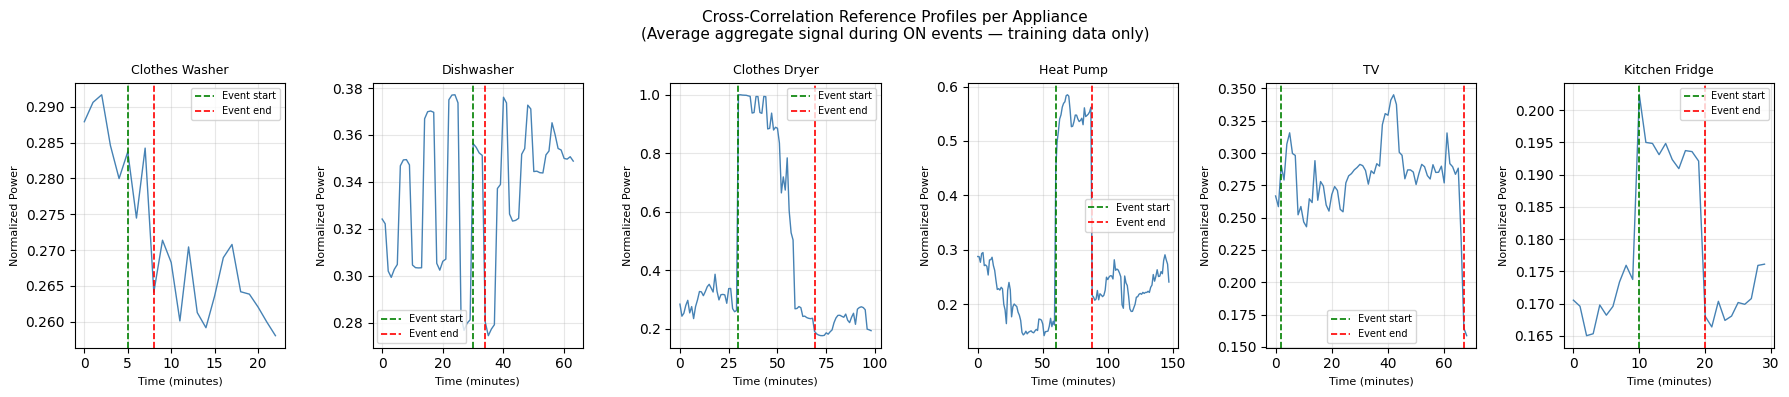

In [24]:
# Filter to only appliances that have profiles
available = [app for app in TARGET_APPLIANCES if app in crosscorr_profiles]

fig, axes = plt.subplots(1, len(available), figsize=(3 * len(available), 4), sharey=False)
if len(available) == 1:
    axes = [axes]  # ensure iterable

for ax, app in zip(axes, available):
    profile = crosscorr_profiles[app]
    c = CONTEXT_CONFIG[app]

    # If your data is in samples, convert to minutes using your sampling interval
    # e.g. if each sample = 1 minute, t is already in minutes
    t = np.arange(len(profile))  # adjust if needed: t = np.arange(len(profile)) / samples_per_minute

    ax.plot(t, profile, color='steelblue', linewidth=1.0)

    event_start = c['lead']                    # in same units as t
    event_end   = len(profile) - c['trail']    # in same units as t

    ax.axvline(event_start, color='green', linestyle='--', linewidth=1.2, label='Event start')
    ax.axvline(event_end,   color='red',   linestyle='--', linewidth=1.2, label='Event end')

    ax.set_title(app, fontsize=9)
    ax.set_xlabel('Time (minutes)', fontsize=8)
    ax.set_ylabel('Normalized Power', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'Cross-Correlation Reference Profiles per Appliance\n'
    '(Average aggregate signal during ON events — training data only)',
    fontsize=11
)
plt.tight_layout()
plt.show()

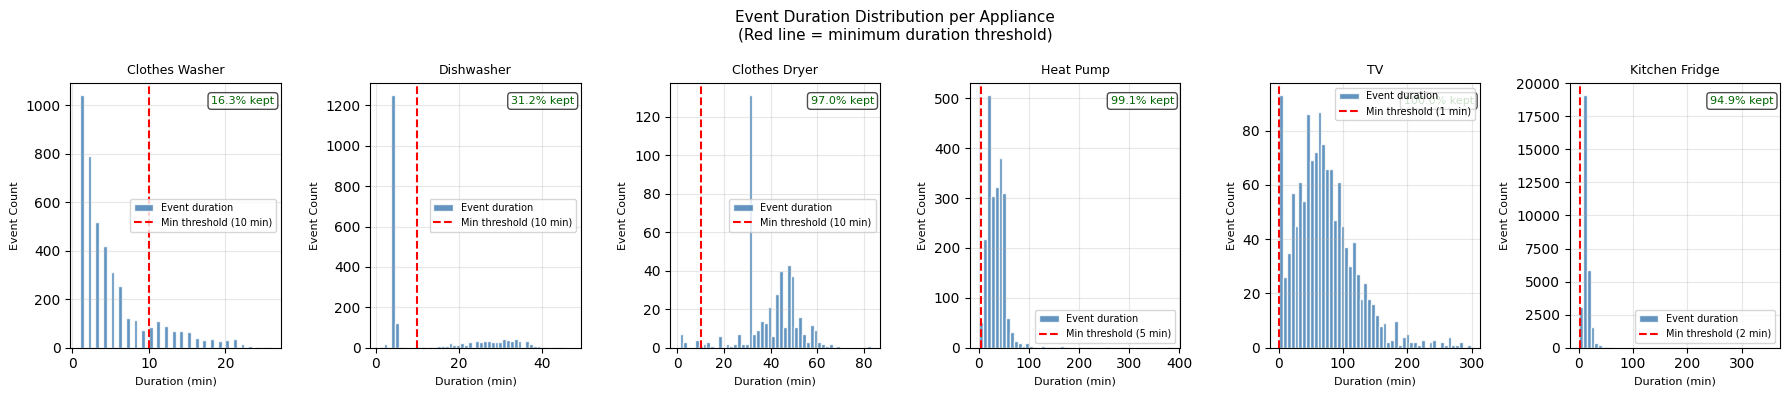

In [26]:
# ── Event Duration Distribution per Appliance ──────────────────────────────
available = [app for app in TARGET_APPLIANCES if app in ampd.columns]

fig, axes = plt.subplots(1, len(available), figsize=(3 * len(available), 4), sharey=False)
if len(available) == 1:
    axes = [axes]

for ax, app in zip(axes, available):
    arr   = ampd[app].values
    is_on = (arr > 0).astype(int)
    diff  = np.diff(is_on, prepend=0)
    starts = np.where(diff == 1)[0]
    ends   = np.where(diff == -1)[0]

    if len(starts) > len(ends):
        ends = np.append(ends, len(arr) - 1)

    durations = ends - starts
    durations = durations[durations > 0]

    min_dur = MIN_EVENT_DURATION.get(app, 2)

    ax.hist(durations, bins=50, color='steelblue', edgecolor='white',
            alpha=0.85, label='Event duration')
    ax.axvline(min_dur, color='red', linestyle='--', linewidth=1.5,
               label=f'Min threshold ({min_dur} min)')

    ax.set_title(app, fontsize=9)
    ax.set_xlabel('Duration (min)', fontsize=8)
    ax.set_ylabel('Event Count', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    pct_kept = (durations >= min_dur).mean() * 100
    ax.text(0.97, 0.95, f'{pct_kept:.1f}% kept',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='darkgreen',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('Event Duration Distribution per Appliance\n(Red line = minimum duration threshold)',
             fontsize=11)
plt.tight_layout()
plt.show()

## 10 · Padding to Fixed Length

All patterns per appliance padded to `MAX_LEN` = longest pattern in training set.
Padding value = 0 (both aggregate and appliance are 0 during OFF periods).
`MAX_LEN` is saved for use in the pipeline notebook.

In [28]:
def pad_patterns(patterns, max_len, n_channels=7):
    """
    Pad all patterns to max_len.

    X: (N, max_len, 7)  — 7-channel aggregate
    y: (N, max_len)     — appliance sequence
    mask: (N, max_len)  — 1 where real data, 0 where padded
    """
    N = len(patterns)
    X    = np.zeros((N, max_len, n_channels), dtype=np.float32)
    y    = np.zeros((N, max_len),             dtype=np.float32)
    mask = np.zeros((N, max_len),             dtype=np.float32)

    for i, pat in enumerate(patterns):
        L = min(pat['length'], max_len)
        X[i, :L, :]  = pat['agg_7ch'][:L]
        y[i, :L]     = pat['app_seq'][:L]
        mask[i, :L]  = 1.0

    return X, y, mask


print('pad_patterns() defined.')

pad_patterns() defined.


## 11 · Build All Datasets

In [29]:
datasets   = {}
max_lens   = {}  # save per appliance for pipeline notebook

for app in TARGET_APPLIANCES:
    if app not in CONTEXT_CONFIG or app not in crosscorr_profiles:
        print(f'Skipping {app} — no config or profile')
        continue

    c         = CONTEXT_CONFIG[app]
    lead      = c['lead']
    trail     = c['trail']
    min_dur   = MIN_EVENT_DURATION.get(app, 2)
    profile   = crosscorr_profiles[app]

    print(f'\n{"="*55}')
    print(f'  {app}  (lead={lead}, trail={trail}, min_dur={min_dur} min)')
    print(f'{"="*55}')

    # Extract patterns from each split
    tr_pats = extract_event_patterns(
        df_train, app, norm_caps, profile, lead, trail, min_dur)
    vl_pats = extract_event_patterns(
        df_val,   app, norm_caps, profile, lead, trail, min_dur)
    te_pats = extract_event_patterns(
        df_test,  app, norm_caps, profile, lead, trail, min_dur)

    print(f'  Events — train: {len(tr_pats)}  val: {len(vl_pats)}  '
          f'test: {len(te_pats)}')

    if len(tr_pats) == 0:
        print(f'  No training events — skipping {app}')
        continue

    # MAX_LEN = longest training pattern
    # (val and test patterns longer than this get truncated)
    max_len = max(p['length'] for p in tr_pats)
    max_lens[app] = max_len
    print(f'  MAX_LEN = {max_len} steps ({max_len} minutes)')

    # Pad all splits to max_len
    X_tr, y_tr, mask_tr = pad_patterns(tr_pats, max_len)
    X_vl, y_vl, mask_vl = pad_patterns(vl_pats if vl_pats else [{'agg_5ch': np.zeros((1,7)), 'app_seq': np.zeros(1), 'length': 1}], max_len)
    X_te, y_te, mask_te = pad_patterns(te_pats if te_pats else [{'agg_5ch': np.zeros((1,7)), 'app_seq': np.zeros(1), 'length': 1}], max_len)

    # If no real val/test patterns exist, use empty arrays
    if len(vl_pats) == 0:
        X_vl = np.zeros((0, max_len, 7), dtype=np.float32)
        y_vl = np.zeros((0, max_len),    dtype=np.float32)
        mask_vl = np.zeros((0, max_len), dtype=np.float32)
    if len(te_pats) == 0:
        X_te = np.zeros((0, max_len, 7), dtype=np.float32)
        y_te = np.zeros((0, max_len),    dtype=np.float32)
        mask_te = np.zeros((0, max_len), dtype=np.float32)

    print(f'  X_train shape: {X_tr.shape}  y_train shape: {y_tr.shape}')
    print(f'  X_val   shape: {X_vl.shape}  X_test  shape: {X_te.shape}')

    datasets[app] = {
        'X_train': X_tr, 'y_train': y_tr, 'mask_train': mask_tr,
        'X_val'  : X_vl, 'y_val'  : y_vl, 'mask_val'  : mask_vl,
        'X_test' : X_te, 'y_test' : y_te, 'mask_test' : mask_te,
        'max_len': max_len,
    }

print(f'\nBuilt datasets for {len(datasets)} appliances.')


  Clothes Washer  (lead=5, trail=15, min_dur=10 min)
  Events — train: 563  val: 30  test: 120
  MAX_LEN = 46 steps (46 minutes)
  X_train shape: (563, 46, 7)  y_train shape: (563, 46)
  X_val   shape: (30, 46, 7)  X_test  shape: (120, 46, 7)

  Dishwasher  (lead=30, trail=30, min_dur=10 min)
  Events — train: 496  val: 32  test: 108
  MAX_LEN = 107 steps (107 minutes)
  X_train shape: (496, 107, 7)  y_train shape: (496, 107)
  X_val   shape: (32, 107, 7)  X_test  shape: (108, 107, 7)

  Clothes Dryer  (lead=30, trail=30, min_dur=10 min)
  Events — train: 361  val: 18  test: 78
  MAX_LEN = 143 steps (143 minutes)
  X_train shape: (361, 143, 7)  y_train shape: (361, 143)
  X_val   shape: (18, 143, 7)  X_test  shape: (78, 143, 7)
Skipping Wall Oven — no config or profile

  Heat Pump  (lead=60, trail=60, min_dur=5 min)
  Events — train: 1685  val: 117  test: 420
  MAX_LEN = 503 steps (503 minutes)
  X_train shape: (1685, 503, 7)  y_train shape: (1685, 503)
  X_val   shape: (117, 503, 7)

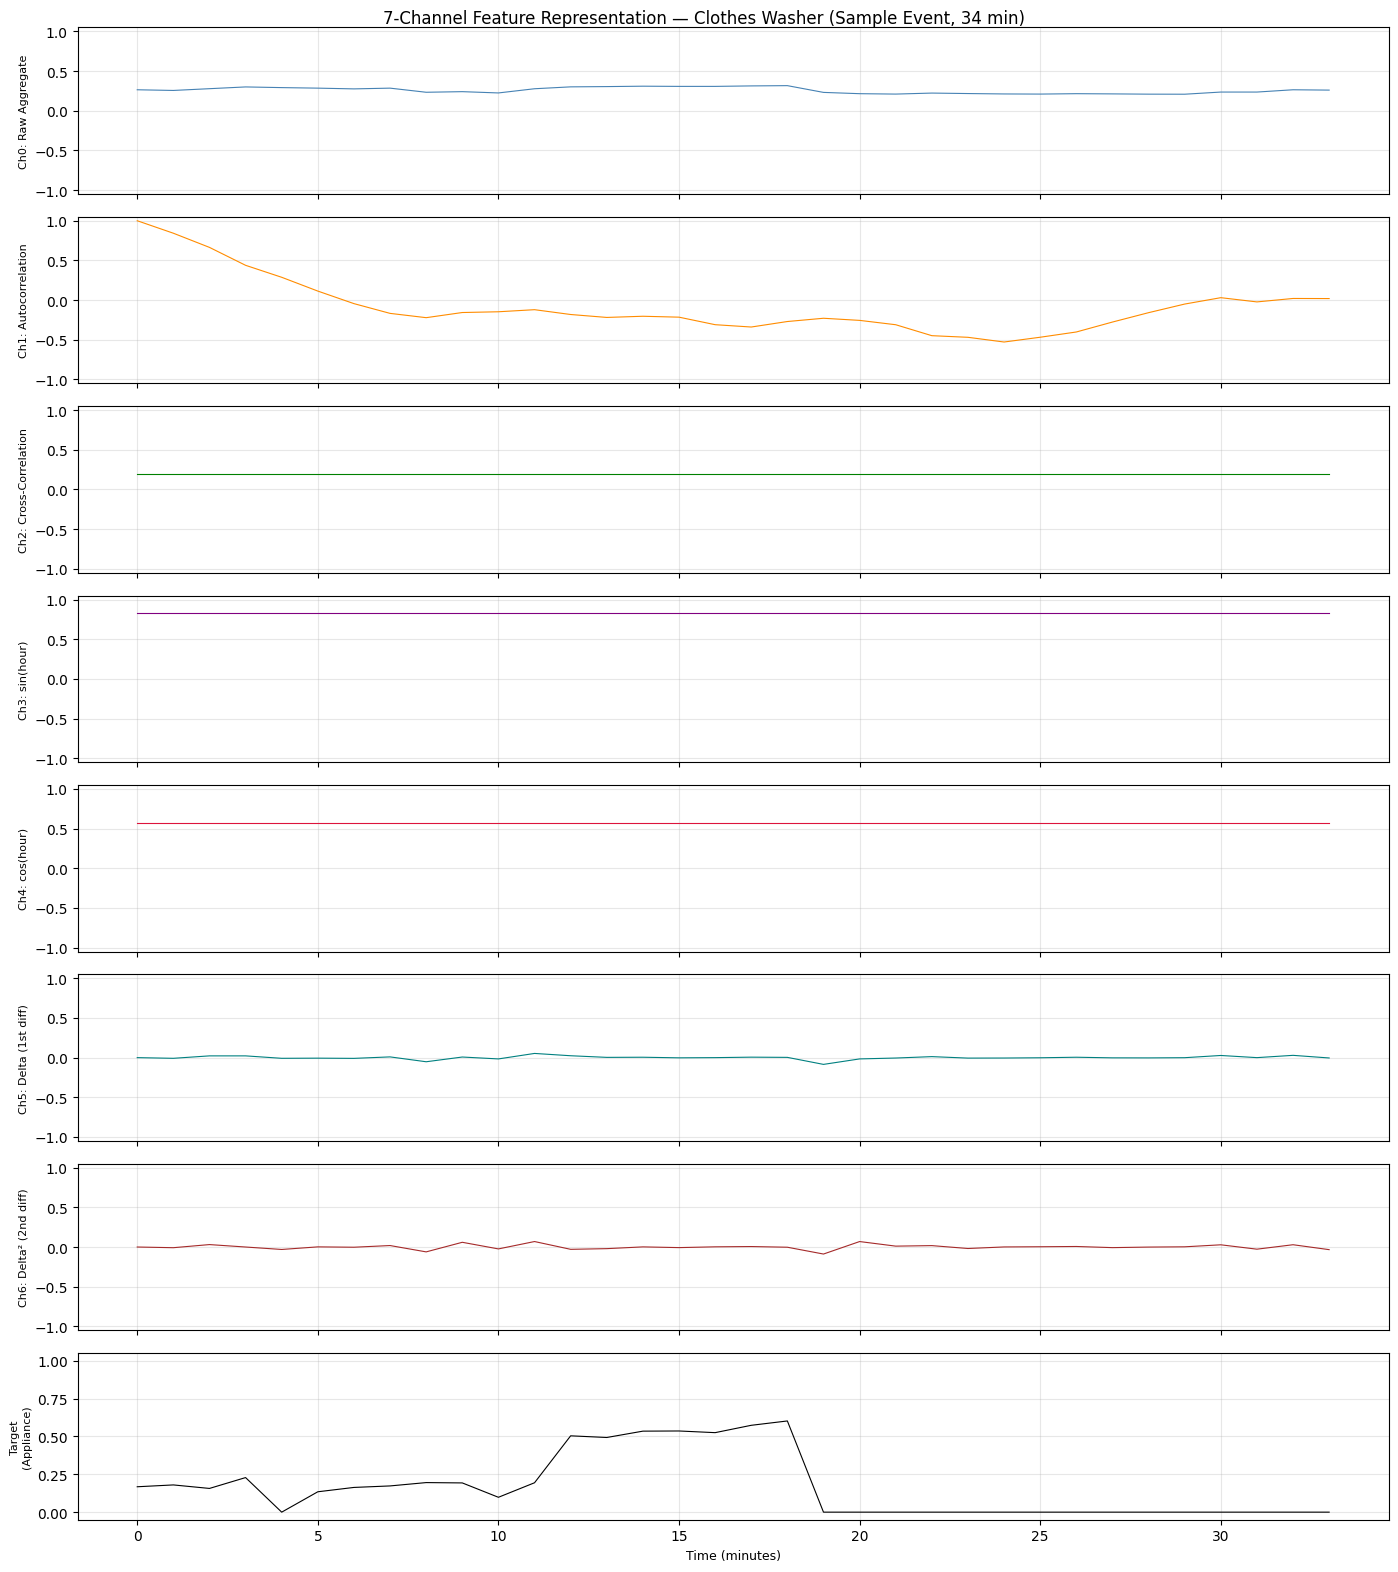

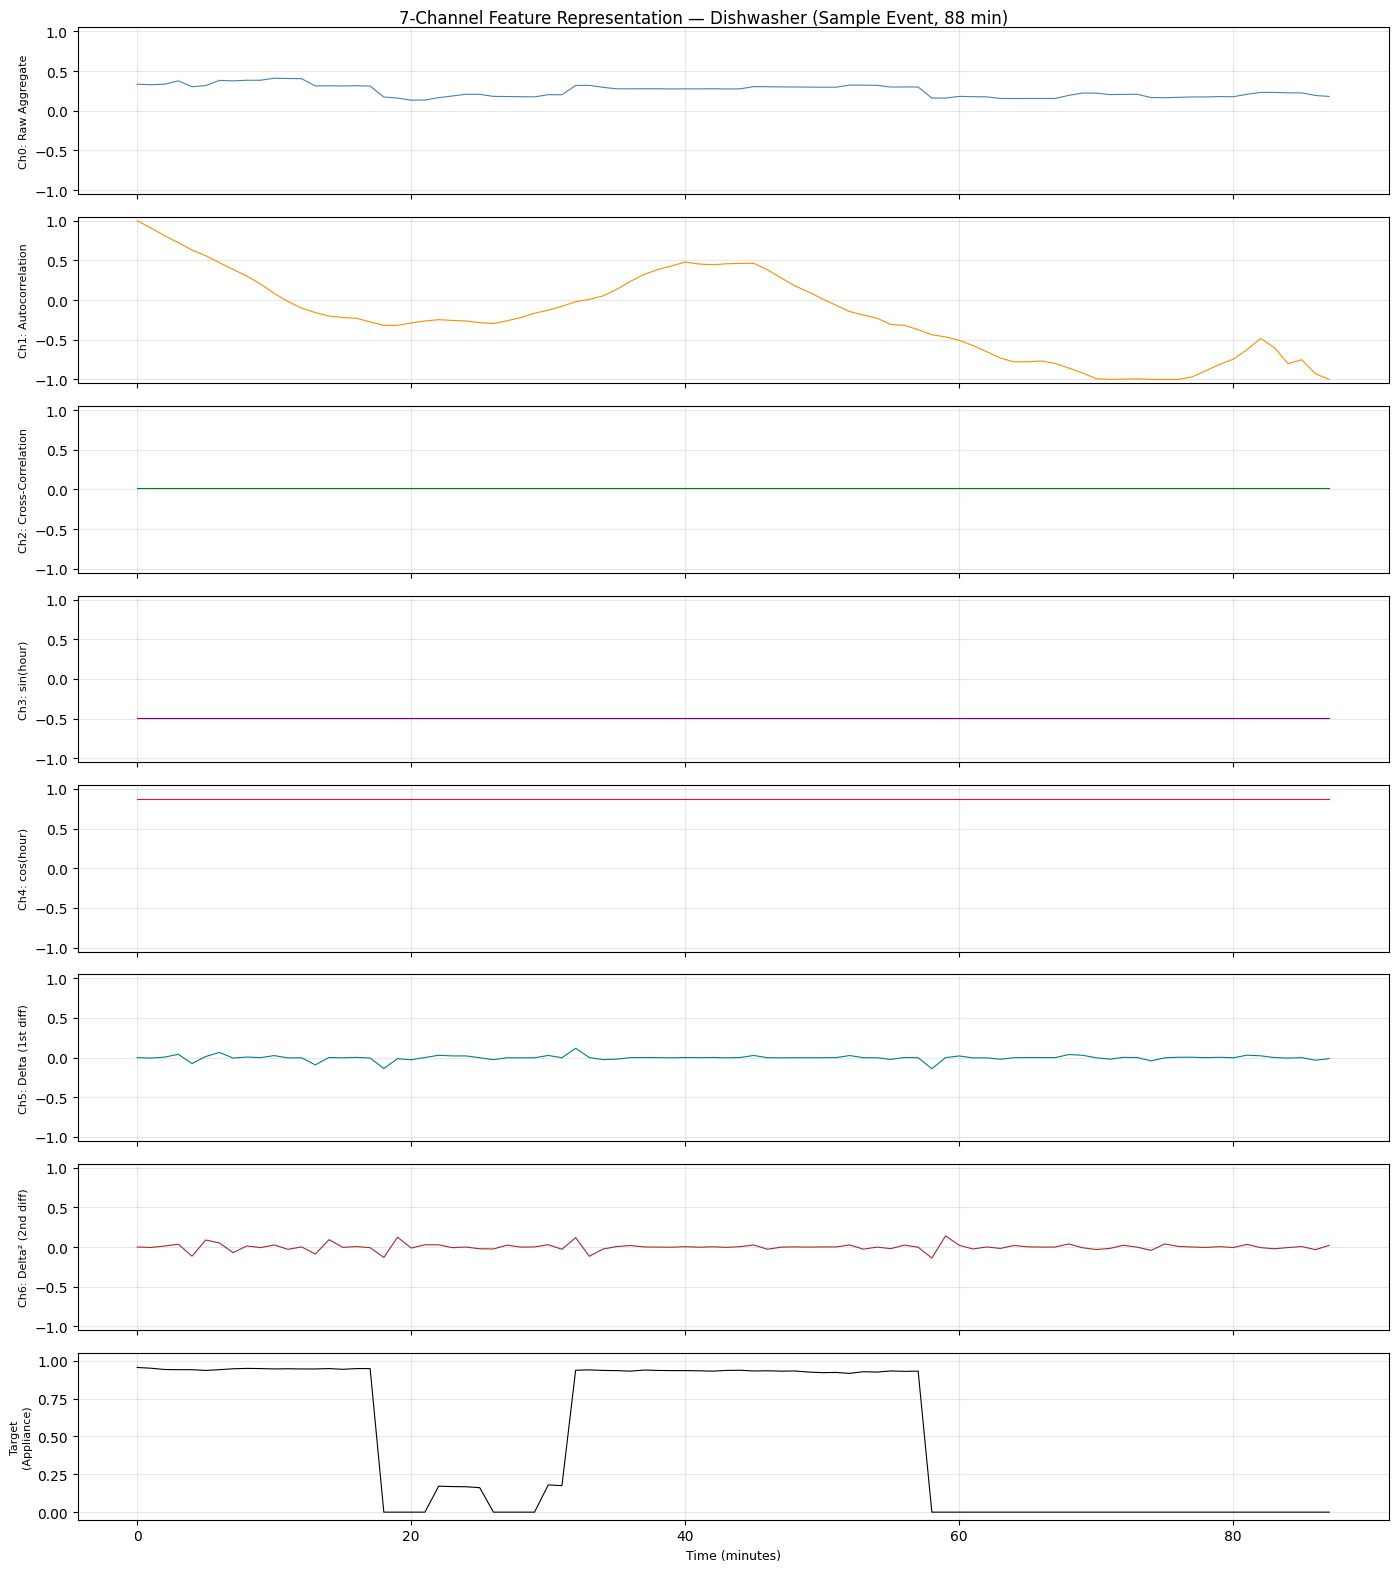

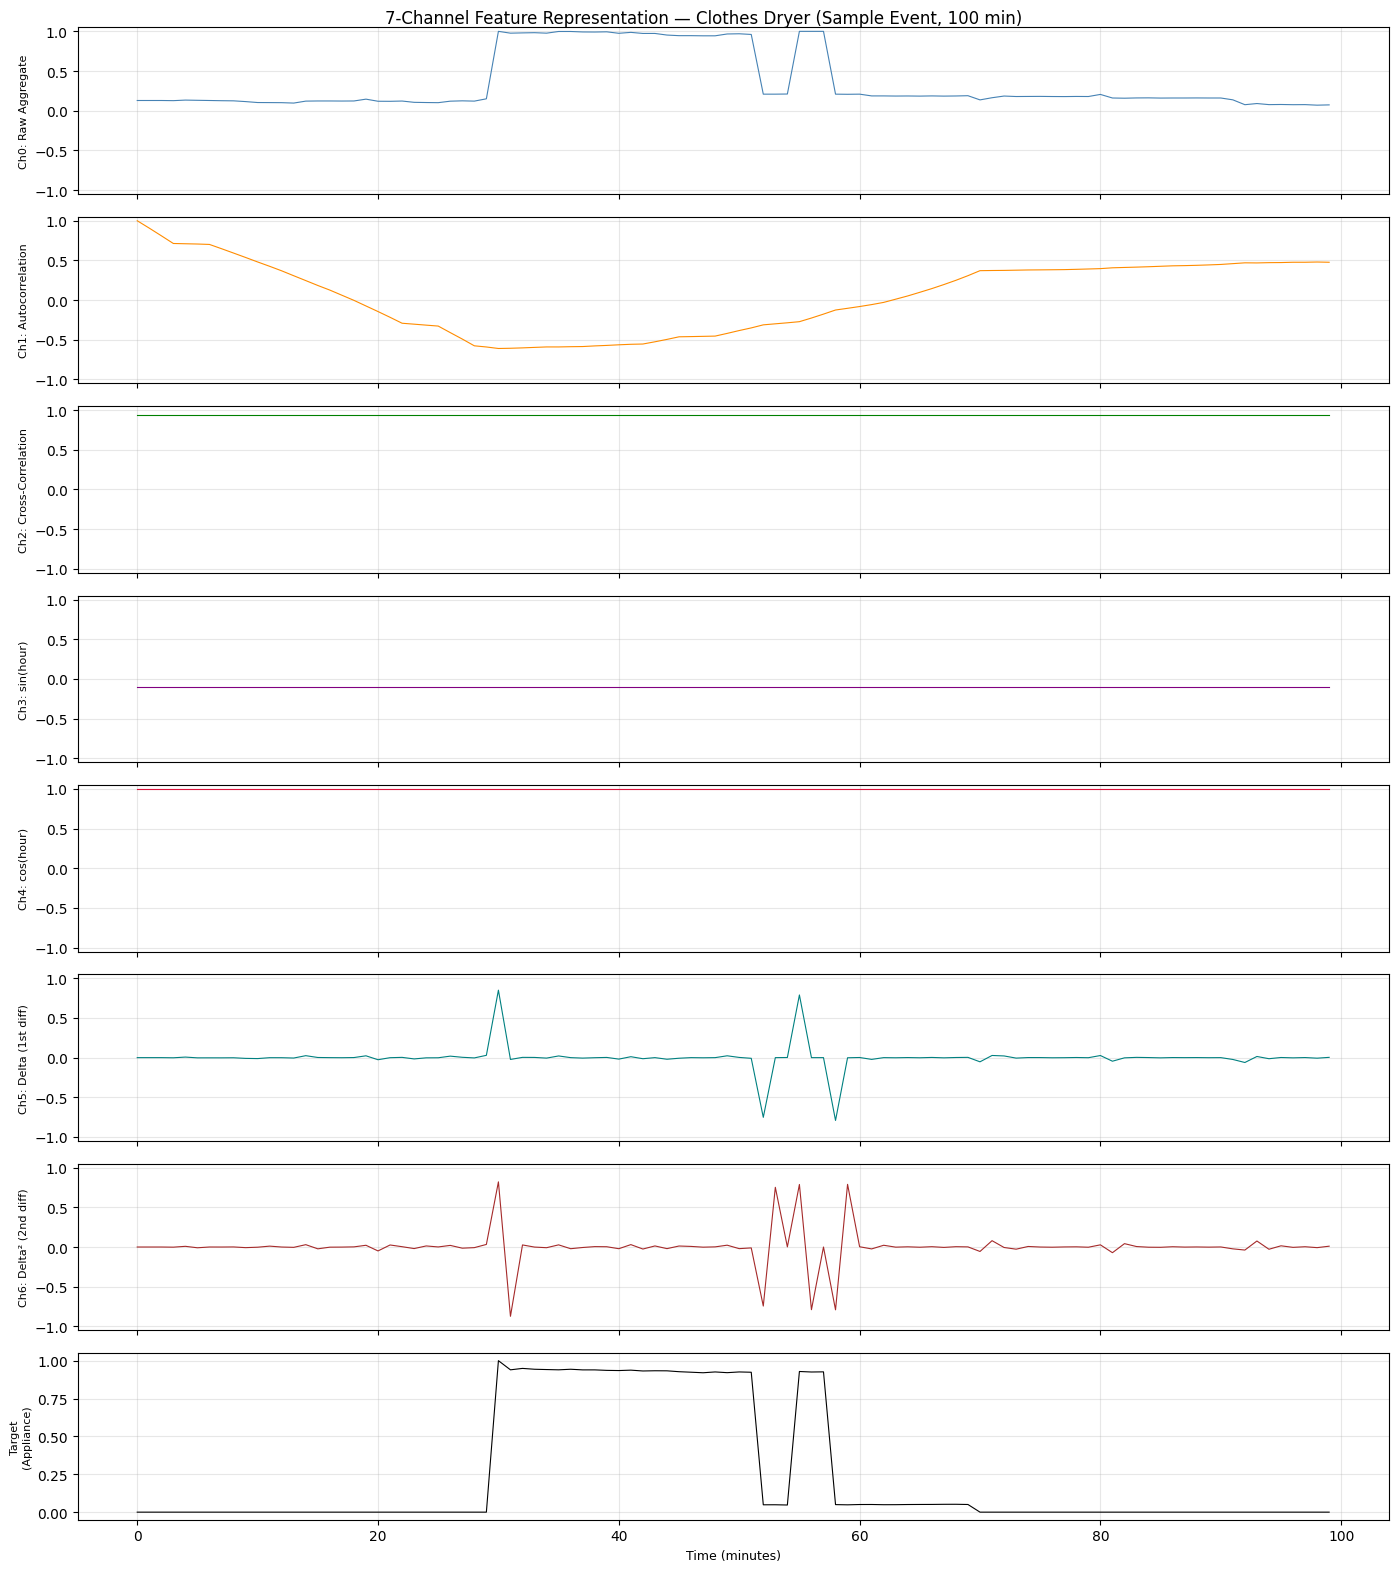

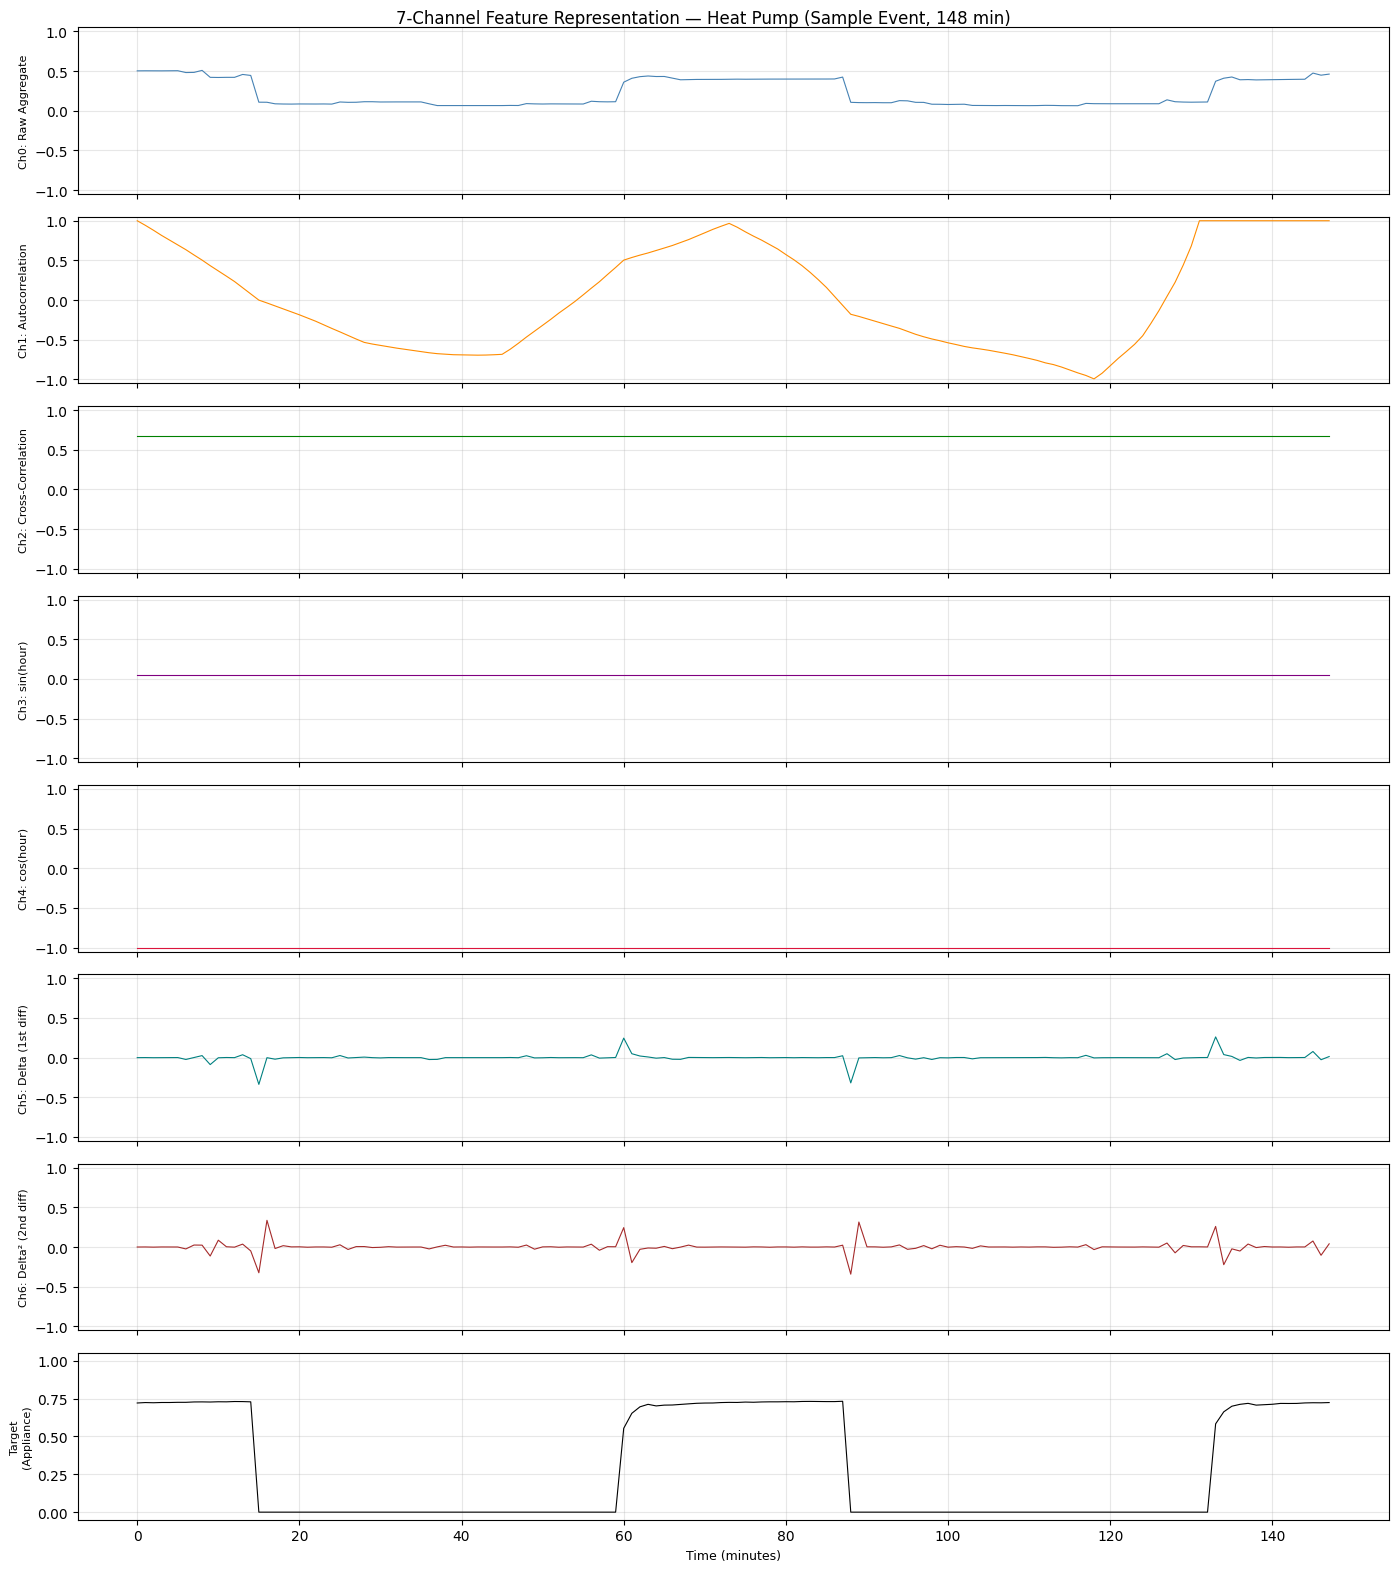

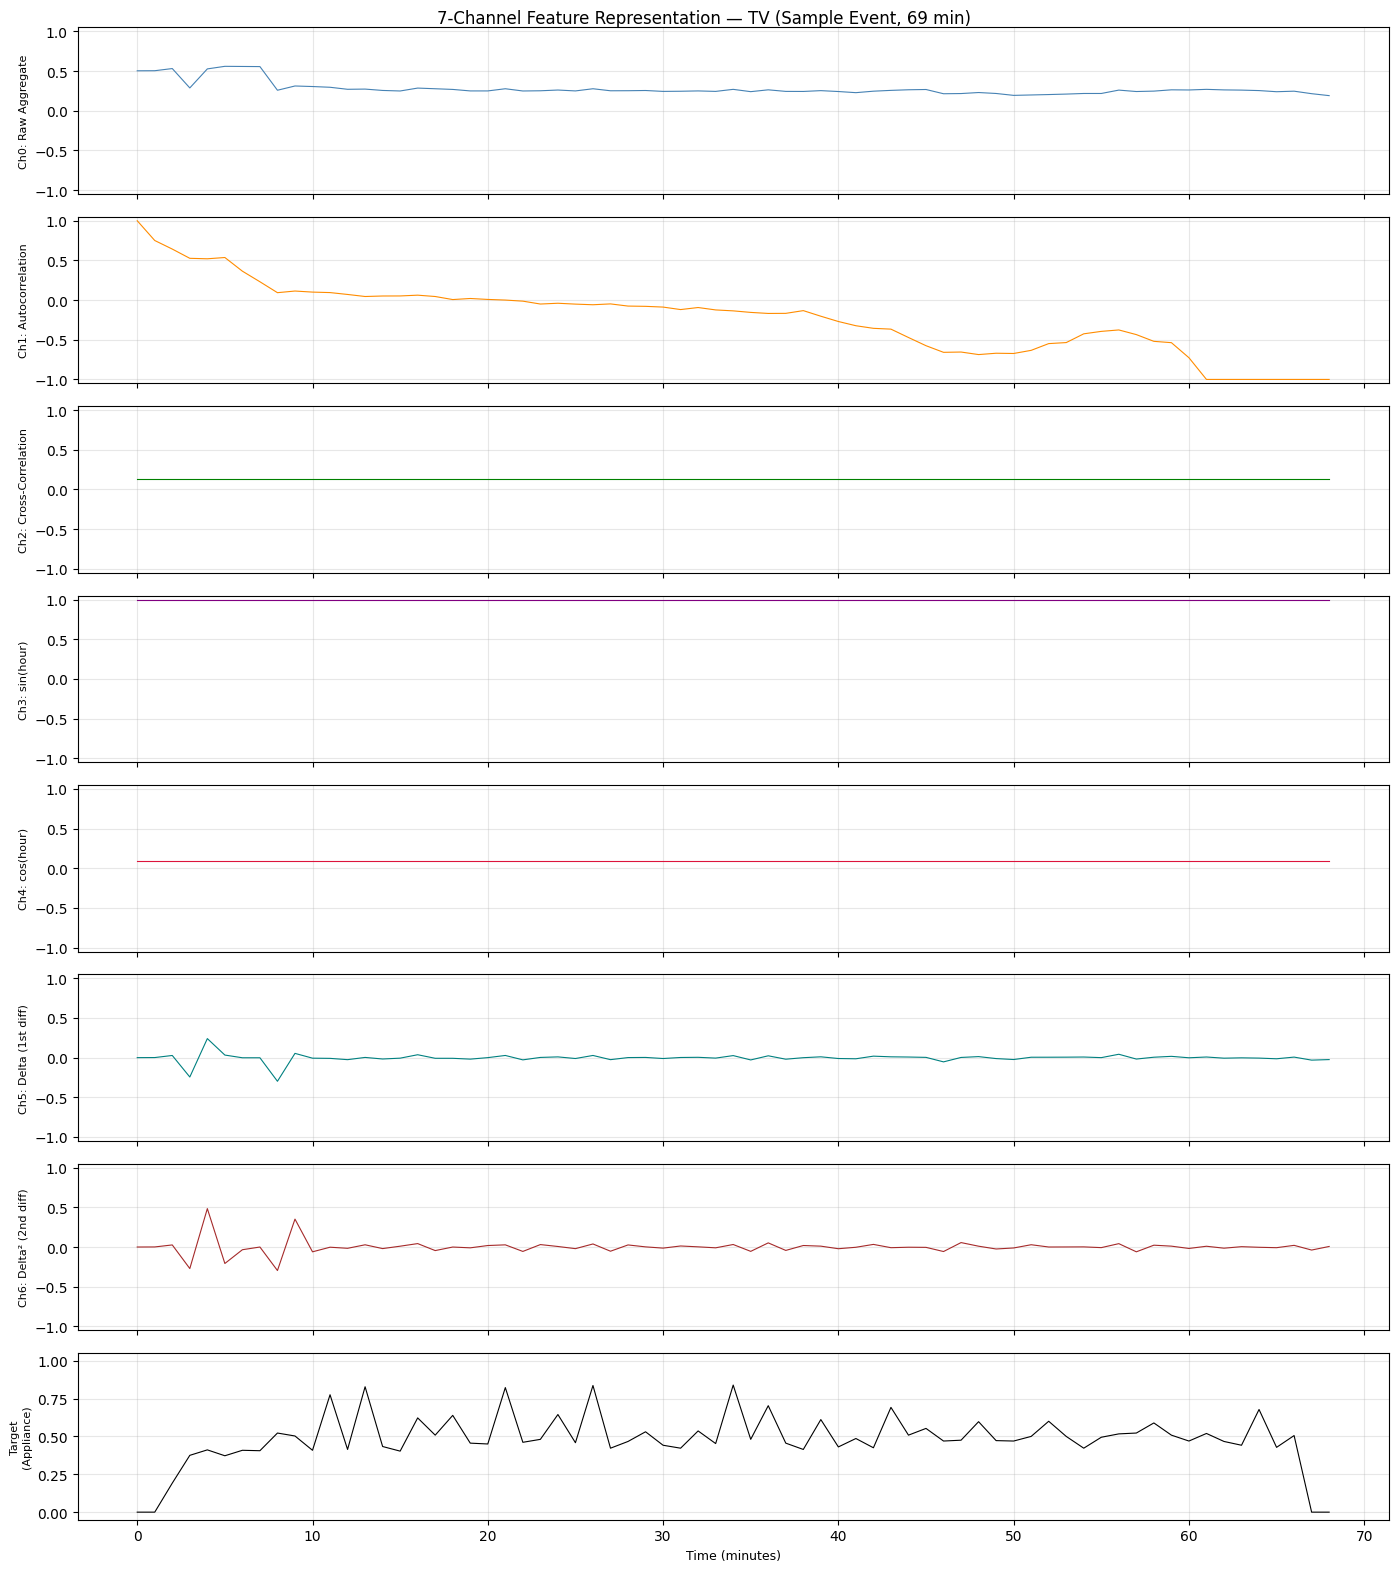

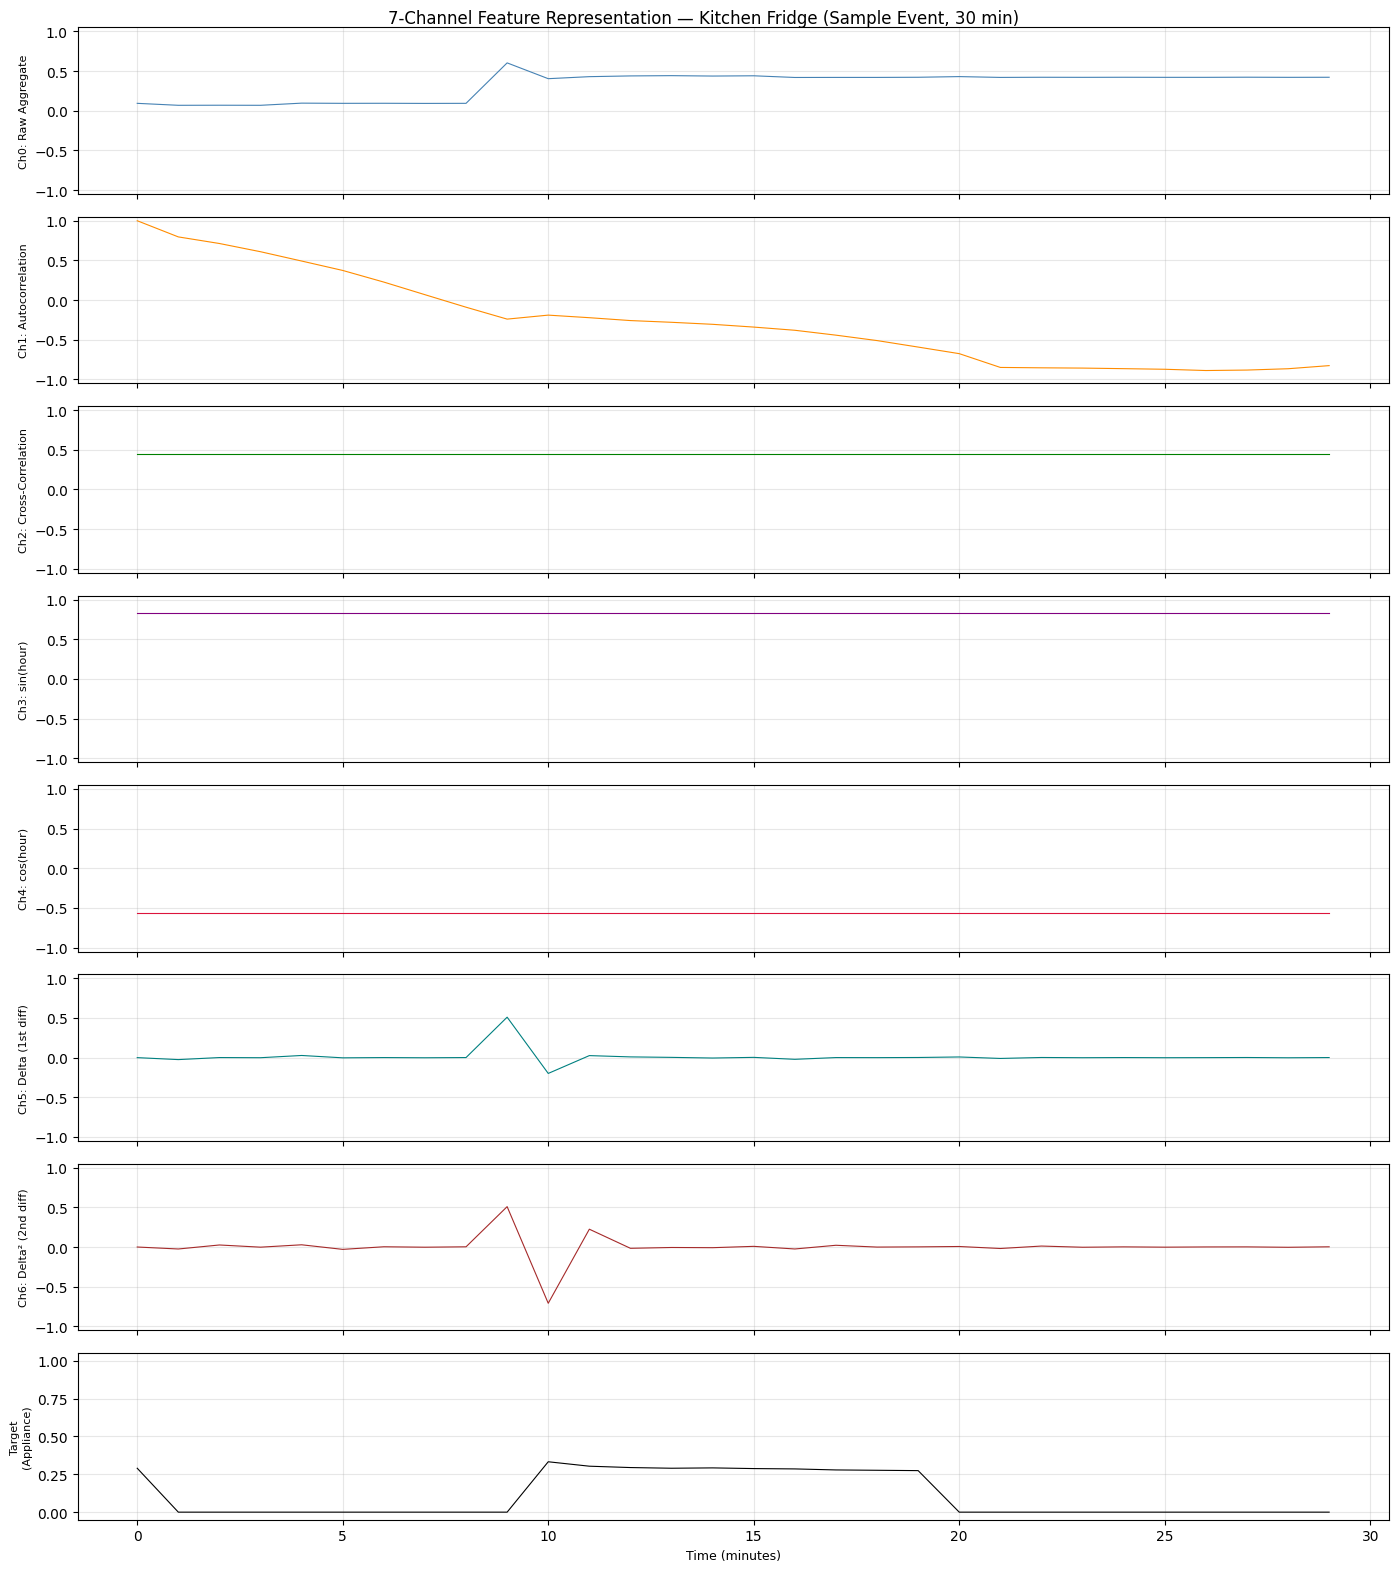

In [30]:
# ── 7-Channel Visualization ────────────────────────────────────────────────
# Run AFTER the datasets loop above

channel_names = [
    'Ch0: Raw Aggregate',
    'Ch1: Autocorrelation',
    'Ch2: Cross-Correlation',
    'Ch3: sin(hour)',
    'Ch4: cos(hour)',
    'Ch5: Delta (1st diff)',
    'Ch6: Delta² (2nd diff)'
]
colors = ['steelblue', 'darkorange', 'green', 'purple', 'crimson', 'teal', 'brown']

for app in TARGET_APPLIANCES:
    if app not in datasets:
        continue

    X_tr = datasets[app]['X_train']  # (N, MAX_LEN, 7)
    y_tr = datasets[app]['y_train']  # (N, MAX_LEN)
    mask = datasets[app]['mask_train']

    if X_tr.shape[0] == 0:
        continue

    # Pick sample closest to median real length
    real_lengths = mask.sum(axis=1).astype(int)
    median_l     = int(np.median(real_lengths))
    idx          = int(np.argmin(np.abs(real_lengths - median_l)))
    L            = real_lengths[idx]

    X_sample = X_tr[idx, :L, :]  # (L, 7)
    y_sample = y_tr[idx, :L]     # (L,)
    t        = np.arange(L)

    fig, axes = plt.subplots(8, 1, figsize=(14, 16), sharex=True)
    fig.suptitle(f'7-Channel Feature Representation — {app} (Sample Event, {L} min)',
                 fontsize=12)

    for ch in range(7):
        axes[ch].plot(t, X_sample[:, ch], color=colors[ch], linewidth=0.8)
        axes[ch].set_ylabel(channel_names[ch], fontsize=8)
        axes[ch].grid(True, alpha=0.3)
        axes[ch].set_ylim(-1.05, 1.05)

    axes[7].plot(t, y_sample, color='black', linewidth=0.8)
    axes[7].set_ylabel('Target\n(Appliance)', fontsize=8)
    axes[7].set_xlabel('Time (minutes)', fontsize=9)
    axes[7].grid(True, alpha=0.3)
    axes[7].set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()

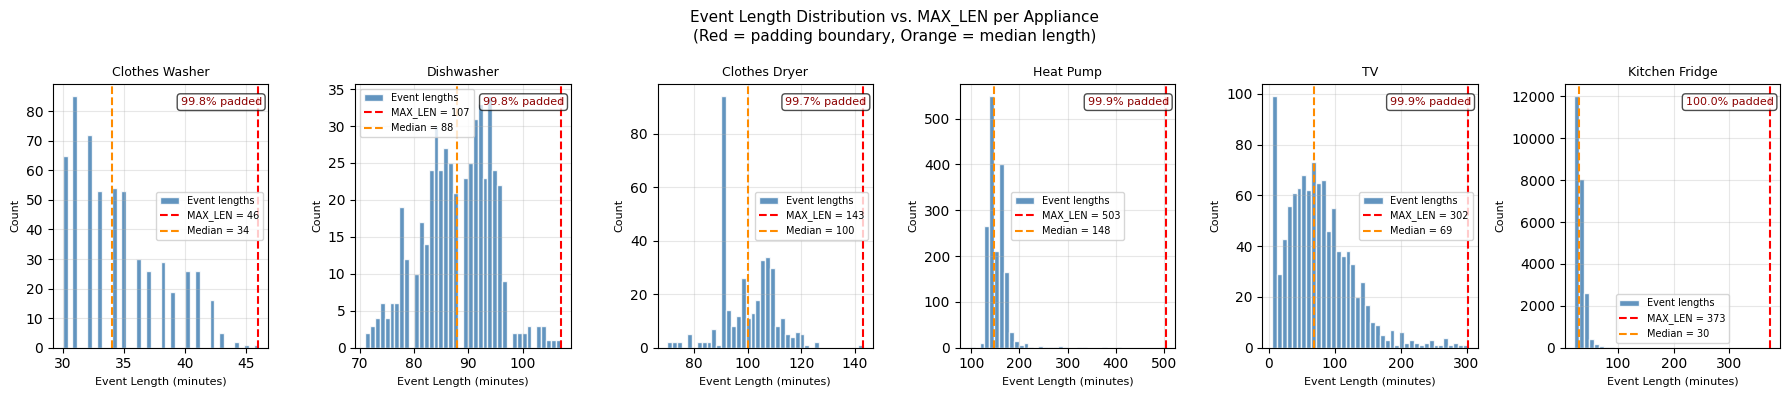

In [32]:
# ── MAX_LEN vs Event Length Distribution ───────────────────────────────────
available = [app for app in TARGET_APPLIANCES if app in datasets]

fig, axes = plt.subplots(1, len(available), figsize=(3 * len(available), 4))
if len(available) == 1:
    axes = [axes]

for ax, app in zip(axes, available):
    mask    = datasets[app]['mask_train']
    max_len = datasets[app]['max_len']
    lengths = mask.sum(axis=1).astype(int)
    lengths = lengths[lengths > 0]

    median_len = int(np.median(lengths))

    ax.hist(lengths, bins=40, color='steelblue', edgecolor='white',
            alpha=0.85, label='Event lengths')
    ax.axvline(max_len, color='red', linestyle='--', linewidth=1.5,
               label=f'MAX_LEN = {max_len}')
    ax.axvline(median_len, color='darkorange', linestyle='--',
               linewidth=1.5, label=f'Median = {median_len}')

    pct_padded = (lengths < max_len).mean() * 100
    ax.text(0.97, 0.95, f'{pct_padded:.1f}% padded',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax.set_title(app, fontsize=9)
    ax.set_xlabel('Event Length (minutes)', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Event Length Distribution vs. MAX_LEN per Appliance\n'
             '(Red = padding boundary, Orange = median length)',
             fontsize=11)
plt.tight_layout()
plt.show()

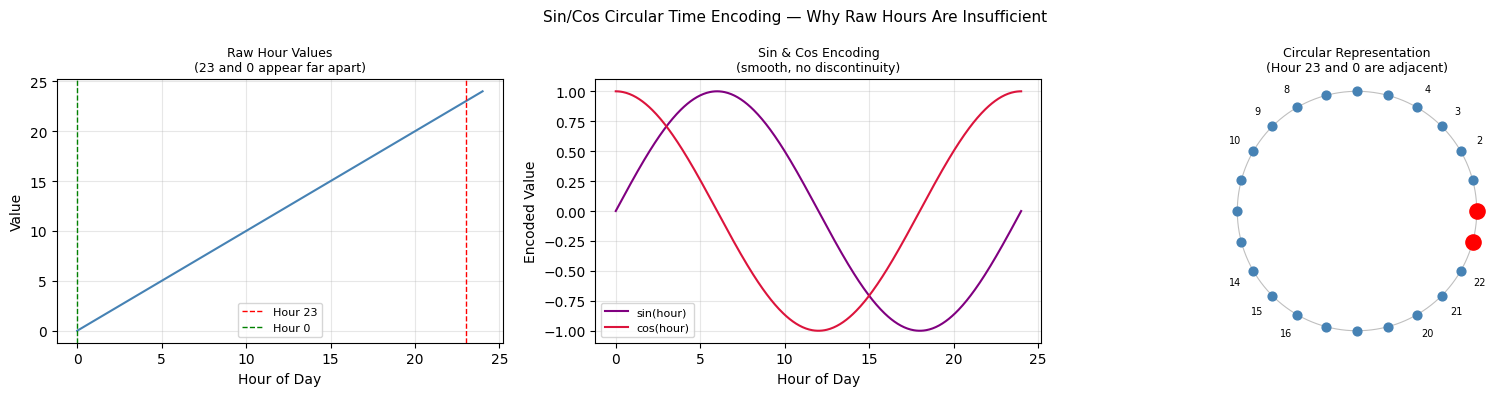

In [33]:
# ── Sin/Cos Circular Time Encoding ─────────────────────────────────────────
hours      = np.linspace(0, 24, 500)
sin_values = np.sin(2 * np.pi * hours / 24)
cos_values = np.cos(2 * np.pi * hours / 24)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: Raw hour — discontinuity problem
axes[0].plot(hours, hours, color='steelblue', linewidth=1.5)
axes[0].axvline(23, color='red',   linestyle='--', linewidth=1, label='Hour 23')
axes[0].axvline(0,  color='green', linestyle='--', linewidth=1, label='Hour 0')
axes[0].set_title('Raw Hour Values\n(23 and 0 appear far apart)', fontsize=9)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Value')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Panel 2: Sin and Cos curves
axes[1].plot(hours, sin_values, color='purple',  linewidth=1.5, label='sin(hour)')
axes[1].plot(hours, cos_values, color='crimson', linewidth=1.5, label='cos(hour)')
axes[1].set_title('Sin & Cos Encoding\n(smooth, no discontinuity)', fontsize=9)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Encoded Value')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3: Circular clock
axes[2].plot(np.cos(np.linspace(0, 2*np.pi, 300)),
             np.sin(np.linspace(0, 2*np.pi, 300)),
             color='gray', linewidth=0.8, alpha=0.5)

for h in range(24):
    x = np.cos(2 * np.pi * h / 24)
    y = np.sin(2 * np.pi * h / 24)
    color = 'red'       if h in [23, 0] else 'steelblue'
    size  = 120         if h in [23, 0] else 40
    axes[2].scatter(x, y, color=color, s=size, zorder=5)
    axes[2].annotate(str(h), (x*1.18, y*1.18), ha='center',
                     va='center', fontsize=7)

axes[2].set_title('Circular Representation\n(Hour 23 and 0 are adjacent)', fontsize=9)
axes[2].set_aspect('equal')
axes[2].axis('off')

plt.suptitle('Sin/Cos Circular Time Encoding — Why Raw Hours Are Insufficient',
             fontsize=11)
plt.tight_layout()
plt.show()

## 12 · Event Count Report

In [34]:
print(f'{"Appliance":<20} {"MAX_LEN":>8} {"Train events":>14} '
      f'{"Val events":>12} {"Test events":>12}')
print('-' * 70)
for app, d in datasets.items():
    print(f'{app:<20} {d["max_len"]:>8} '
          f'{len(d["X_train"]):>14,} '
          f'{len(d["X_val"]):>12,} '
          f'{len(d["X_test"]):>12,}')

Appliance             MAX_LEN   Train events   Val events  Test events
----------------------------------------------------------------------
Clothes Washer             46            563           30          120
Dishwasher                107            496           32          108
Clothes Dryer             143            361           18           78
Heat Pump                 503          1,685          117          420
TV                        302          1,059           65          210
Kitchen Fridge            373         23,348        1,383        4,019


## 13 · Visualise Extracted Patterns (sanity check)

Shows the first ON event for each appliance — aggregate vs appliance, all 5 channels.

## 14 · Export Datasets

In [36]:
# We save X, y, and mask as separate numpy files per appliance per split.
# CSV would be too large for sequences — numpy is faster and smaller.

for app, d in datasets.items():
    safe = app.replace(' ', '_').replace('/', '-')
    app_dir = os.path.join('nilm_datasets', safe)
    os.makedirs(app_dir, exist_ok=True)

    for split in ['train', 'val', 'test']:
        X    = d[f'X_{split}']     # (N, max_len, 7)
        y    = d[f'y_{split}']     # (N, max_len)
        mask = d[f'mask_{split}']  # (N, max_len)

        if len(X) == 0:
            print(f'  {app} {split}: empty — skipped')
            continue

        np.save(os.path.join(app_dir, f'X_{split}.npy'),    X)
        np.save(os.path.join(app_dir, f'y_{split}.npy'),    y)
        np.save(os.path.join(app_dir, f'mask_{split}.npy'), mask)

        print(f'  {app:<20} {split:<6}: '
              f'X={X.shape}  y={y.shape}')

# Save max_lens for pipeline notebook
pd.DataFrame([max_lens]).to_csv('nilm_datasets/max_lens.csv', index=False)
print('\nSaved: nilm_datasets/max_lens.csv')
print('Export complete.')

  Clothes Washer       train : X=(563, 46, 7)  y=(563, 46)
  Clothes Washer       val   : X=(30, 46, 7)  y=(30, 46)
  Clothes Washer       test  : X=(120, 46, 7)  y=(120, 46)
  Dishwasher           train : X=(496, 107, 7)  y=(496, 107)
  Dishwasher           val   : X=(32, 107, 7)  y=(32, 107)
  Dishwasher           test  : X=(108, 107, 7)  y=(108, 107)
  Clothes Dryer        train : X=(361, 143, 7)  y=(361, 143)
  Clothes Dryer        val   : X=(18, 143, 7)  y=(18, 143)
  Clothes Dryer        test  : X=(78, 143, 7)  y=(78, 143)
  Heat Pump            train : X=(1685, 503, 7)  y=(1685, 503)
  Heat Pump            val   : X=(117, 503, 7)  y=(117, 503)
  Heat Pump            test  : X=(420, 503, 7)  y=(420, 503)
  TV                   train : X=(1059, 302, 7)  y=(1059, 302)
  TV                   val   : X=(65, 302, 7)  y=(65, 302)
  TV                   test  : X=(210, 302, 7)  y=(210, 302)
  Kitchen Fridge       train : X=(23348, 373, 7)  y=(23348, 373)
  Kitchen Fridge       val   : X

In [ ]:
print('fhf')

fhf)
